# Full Reaction Network

\begin{align}
CO_2 + 3H_2 &\rightleftharpoons CH_3OH + H_2O\\
CO + 2H_2 &\rightleftharpoons CH_3OH\\
CO_2 + H_2 &\rightleftharpoons CO + H_2O\\
2CH_3OH &\rightleftharpoons CH_3OCH_3 + H_2O
\end{align}


# Yield

"How much of Educt i is converted into Product k"

\begin{equation}
    Y_{k} = \frac{\nu_i}{\nu_k} \, \frac{n_{k, 0}-n_{k}}{n_{i,0}}
\end{equation}

Educt is CO2 and H2, everything else is a byproduct

# Reaction extend

\begin{equation}
    \xi_{i} = \frac{n_i - n_{i,0}}{\nu_i}
\end{equation}

# Importing the researched Glenn Data-Sets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp
import pandas as pd

# Pfad zu den Daten
data_path = r'c:\Users\Peter\Documents\Uni\Master\CRE 3\CRE3-Assignment-2\data_literature\NASA_shomate_coefficients_full.csv' # Windows Version
# data_path = r'/home/pit/Uni/Master/CRE3/CRE3-Assignment-2/data_literature/NASA_shomate_coefficients_full.csv' # Linux Version

# NASA Glenn Koeffizienten laden
df_nasa = pd.read_csv(data_path)
print("\nGeladene Spezies:")
print(df_nasa[['species_name', 'formula', 'T1_min_K', 'T1_max_K', 'T2_min_K', 'T2_max_K']].to_string())


Geladene Spezies:
  species_name  formula  T1_min_K  T1_max_K  T2_min_K  T2_max_K
0           H2       H2     200.0    1000.0    1000.0    6000.0
1          H2O      H2O     200.0    1000.0    1000.0    6000.0
2           CO       CO     200.0    1000.0    1000.0    6000.0
3          CO2      CO2     200.0    1000.0    1000.0    6000.0
4        CH3OH    CH3OH     200.0    1000.0    1000.0    6000.0
5      CH3OCH3  CH3OCH3     200.0    1000.0    1000.0    6000.0


# Formulating the Matrix of stoichometric coefficients

# NOTE: this is useless up until now, if i dont find a use i will email Franz to find out, if we HAVE to use it.

\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2
    \end{bmatrix}
\end{equation}

To ensure, that the mathematical method of the matrix of stochiometric coefficients is possible, we need to snure, that $N_{1,1}$ has an inverse matrix that can be calculated. A quick calculation shows, that R3 is equal to R1 -R2 ($R_1 - R_2 = R_3$). 

Therefor, R4 and R3 are interchanged, to enable a succesfull solution of the mathematical approach:

\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2  \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 
    \end{bmatrix}
\end{equation}

In [2]:
from numpy.linalg import matrix_rank

# --- DME Synthesis Stoichiometric Analysis ---
# Component Order: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]
# Reaction Order adjusted: [R1, R2, R4, R3] to ensure N11 is non-singular
# This order ensures Key Components are in the first 3 rows (Rank = 3)

n_matrix = np.array([
    [ 0, -1,  0,  1],  # CO    
    [-1,  0,  0, -1],  # CO2   
    [ 0,  0,  1,  0],  # CH3OCH3 (DME) -> Now independent in the 3rd column (because R1-R2=R3)
    [-3, -2,  0, -1],  # H2    
    [ 1,  0,  1,  1],  # H2O   
    [ 1,  1, -2,  0]   # CH3OH
])

# Get the transposed matrix (N^T)
n_transposed = n_matrix.T

# Determine the rank of the matrix
n_rank = matrix_rank(n_matrix)

print("--- DME Synthesis Stoichiometric Analysis ---")
print(f"Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]")
print("\nTransposed Matrix (N^T):")
print(n_transposed)
print(f"\nMatrix Rank (Number of Key Reactions): {n_rank}")

# creating a list of species and their corresponding indexes in the transposed matrix/reactions 1-4
# Index 0 = R1, Index 1 = R2, Index 2 = R4, Index 3 = R3 (adjusted order for independence)
species = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']
reaction_tuples = np.full((len(n_transposed), len(species)), '', dtype=object)

for i in range(4):
    for j in range(len(species)):
        reaction_tuples[i][j] = (species[j], n_transposed[i][j])

--- DME Synthesis Stoichiometric Analysis ---
Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]

Transposed Matrix (N^T):
[[ 0 -1  0 -3  1  1]
 [-1  0  0 -2  0  1]
 [ 0  0  1  0  1 -2]
 [ 1 -1  0 -1  1  0]]

Matrix Rank (Number of Key Reactions): 3


The rank is $R_N=3$, which means that three key reactions and components are sufficient to describe the reaction extent based on stoichiometry. According to the order of components and reactions chosen for the matrix of stoichiometric coefficients, $CO$, $CO_2$, $CH_3OCH_3 (DME)$ are the key components. 

From this, we define the Matrices $N_{1,1}$, $N_{1,2}$, $N_{2,1}$ and $N_{2,2}$

In [3]:
# Defining the Matrizes N_{1,1}, N_{1,2}, N_{2,1} and N_{2,2}
N_11 = n_matrix[:3, :3]  # Key Reactions (R1, R2, R4) and Key Components (CO, CO2, CH3OCH3)
N_12 = n_matrix[:3, 3:]  # Key Reactions (R1, R2, R4) and Non-Key Components (H2, H2O, CH3OH)
N_21 = n_matrix[3:, :3]  # Non-Key Reactions (R3) and Key Components (CO, CO2, CH3OCH3)
N_22 = n_matrix[3:, 3:]  # Non-Key Reactions (R3) and Non-Key Components (H2, H2O, CH3OH)

print("\nN_11 (Key Reactions vs Key Components):")
print(N_11)
print("\nN_12 (Non-Key Reactions vs Key Components):")
print(N_12)
print("\nN_21 (Key Reactions vs Non-Key Components):")
print(N_21)
print("\nN_22 (Non-Key Reactions vs Non-Key Components):")
print(N_22)


N_11 (Key Reactions vs Key Components):
[[ 0 -1  0]
 [-1  0  0]
 [ 0  0  1]]

N_12 (Non-Key Reactions vs Key Components):
[[ 1]
 [-1]
 [ 0]]

N_21 (Key Reactions vs Non-Key Components):
[[-3 -2  0]
 [ 1  0  1]
 [ 1  1 -2]]

N_22 (Non-Key Reactions vs Non-Key Components):
[[-1]
 [ 1]
 [ 0]]


## 2. Thermodynamische Funktionen (Glenn-Gleichung NASA-Format)

NASA-Glenn Koeffizienten (7 pro Bereich):
$$\frac{C_p^\circ(T)}{R} = a_1 T^{-2} + a_2 T^{-1} + a_3 + a_4 T + a_5 T^2 + a_6 T^3 + a_7 T^4$$

$$\frac{H^\circ(T)}{RT} = -a_1 T^{-2} + a_2 \frac{\ln T}{T} + a_3 + \frac{a_4}{2} T + \frac{a_5}{3} T^2 + \frac{a_6}{4} T^3 + \frac{a_7}{5} T^4 + \frac{b_1}{T}$$

$$\frac{S^\circ(T)}{R} = -\frac{a_1}{2} T^{-2} - a_2 T^{-1} + a_3 \ln T + a_4 T + \frac{a_5}{2} T^2 + \frac{a_6}{3} T^3 + \frac{a_7}{4} T^4 + b_2$$


In [4]:
# Storing Glenn-coefficients in Dictionary
GLENN_NASA = {}

for _, row in df_nasa.iterrows():
    species = row['species_name'].strip()
    # Checks, if the given row has only one or two temperature ranges. If T2_min_K is NaN, there is only one range.
    if pd.isna(row['T2_min_K']): 
        # Only one Temperature range
        ranges = [(
            row['T1_min_K'], row['T1_max_K'],
            row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
            row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
        )]
    else:
        # Two temperature ranges
        ranges = [
            (
                row['T1_min_K'], row['T1_max_K'],
                row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
                row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
            )
        ]
        # Additional check to ensure that the second range is valid before appending
        if not pd.isna(row['T2_min_K']):
            ranges.append((
                row['T2_min_K'], row['T2_max_K'],
                row['a1_T2'], row['a2_T2'], row['a3_T2'], row['a4_T2'], row['a5_T2'],
                row['a6_T2'], row['a7_T2'], row['b1_T2'], row['b2_T2']
            ))
    GLENN_NASA[species] = ranges

# getting the enthalpy of formation at 298 K for a given species:
def get_hf298(species):
    dict_species = df_nasa.set_index('species_name')
    return dict_species.loc[species]['hf298_J_mol']



## Coding the NASA-Glenn-equations

In [5]:
R = 8.314  # J/(mol*K)

def cp_T(species, T):
    """
    Calculate the specific heat capacity (Cp) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - Cp: Specific heat capacity in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate Cp using the NASA polynomial coefficients
            Cp = R * (a1 * T**(-2) + a2 * T**(-1) + a3 + a4 * T + a5 * T**2 + a6 * T**3 + a7 * T**4)
            return Cp
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def hf_T(species, T):
    """
    Calculate the enthalpy of formation (hf) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - hf: Enthalpy of formation in J/mol (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate the change in enthalpy from 298 K to T using the NASA polynomial coefficients
            # IMPORTANT: The NASA polynomials give the specific heat capacity (Cp) as a function of temperature. To get the enthalpy at temperature T, we need to integrate Cp from 298 K to T and add the enthalpy of formation at 298 K (hf298).
            # The addition of hf298 is already included in the coefficient b1, which is the constant term in the enthalpy polynomial. Therefore, we can directly use the polynomial to calculate the enthalpy at temperature T.
            delta_hf = R * T * ((-a1 * T**(-2)) + a2 * (np.log(T)/T) + a3 + (a4/2) * T + (a5/3) * T**2 + (a6/4) * T**3 + (a7/5) * T**4 + b1/T )
            return delta_hf
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def s_T(species, T):
    """
    Calculate the entropy (S) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - S: Entropy in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate S using the NASA polynomial coefficients
            S = R * ((-(a1/2) * T**(-2)) - a2 * T**(-1) + a3 * np.log(T) + a4 * T + (a5/2) * T**2 + (a6/3) * T**3 + (a7/4) * T**4 + b2)
            return S
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

print("\n--- Thermodynamic Properties Calculation ---")
# Validation values for Temperatures 298,15 K, 500 K, 1000 K, printed as a table for readability
validation_temperatures = [298.15, 500, 1000]
validation_species = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']
print(f"{'Species':<10} {'T (K)':<10} {'Cp (J/mol*K)':<20} {'H°-H°(298.15 K) (kJ/mol)':<28} {'S (J/mol*K)':<20}")
for T in validation_temperatures:
    print("-" * 80)
    for sp in validation_species:
        cp_value = cp_T(sp, T)
        hf_value = (hf_T(sp, T)-get_hf298(sp)) / 1000  # Convert to kJ/mol
        s_value = s_T(sp, T)
        print(f"{sp:<10} {T:<10.2f} {cp_value:<20.2f} {hf_value:<28f} {s_value:<20.2f}")


--- Thermodynamic Properties Calculation ---
Species    T (K)      Cp (J/mol*K)         H°-H°(298.15 K) (kJ/mol)     S (J/mol*K)         
--------------------------------------------------------------------------------
CO         298.15     29.14                0.006780                     197.65              
CO2        298.15     37.13                0.024137                     213.77              
CH3OCH3    298.15     65.82                0.011293                     267.36              
H2         298.15     28.83                -0.000000                    130.67              
H2O        298.15     33.59                0.014833                     188.82              
CH3OH      298.15     44.04                0.012325                     239.80              
--------------------------------------------------------------------------------
CO         500.00     29.79                5.937225                     212.82              
CO2        500.00     44.62                8.330

# Validating the programmed Formulas

To be sure our implementation is correct, we compare our Results for all species at three Temperatures (298,15 K, 500 K, 1000 K) with thermodynamical Data from standart literature (Chase, M. W. Jr. (1998). NIST-JANAF Thermochemical Tables, 4th Edition. Journal of Physical and Chemical Reference Data, Monograph No. 9. American Chemical Society / American Institute of Physics.) The Standart Data is seen in the table below, our results can be seen as the print-output of the code-cell above.

## Thermodynamic Data (gas phase, Ideal gas, p° = 0,1 MPa)
**Source:** Chase, M.W., Jr. (1998). *NIST-JANAF Thermochemical Tables*, 4th Ed.
*J. Phys. Chem. Ref. Data, Monograph 9.* https://janaf.nist.gov

| Spezies | T (K) | Cp° (J·mol⁻¹·K⁻¹) | H°−H°(298.15) (kJ·mol⁻¹) | S° (J·mol⁻¹·K⁻¹) | log Kf (−) |
|---------|-------|--------------------|--------------------------|-------------------|------------|
| CO      | 298.15 | 29.142            | 0.000                    | 197.653           | 24.030     |
| CO₂     | 298.15 | 37.129            | 0.000                    | 213.795           | 69.095     |
| H₂      | 298.15 | 28.836            | 0.000                    | 130.680           | 0.000      |
| H₂O(g)  | 298.15 | 33.590            | 0.000                    | 188.834           | 40.047     |
| CH₃OH(g)| 298.15 | 44.06             | 0.000                    | 239.9             | 28.44 *    |
|||||||
| CO      | 500    | 29.794            | 5.931                    | 212.831           | 16.236     |
| CO₂     | 500    | 44.627            | 8.305                    | 234.901           | 41.259     |
| H₂      | 500    | 29.260            | 5.882                    | 145.737           | 0.000      |
| H₂O(g)  | 500    | 35.226            | 6.925                    | 206.534           | 22.884     |
| CH₃OH(g)| 500    | —                 | —                        | —                 | —          |
|||||||
| CO      | 1000   | 33.183            | 21.690                   | 234.538           | 10.461     |
| CO₂     | 1000   | 54.308            | 33.397                   | 269.299           | 20.679     |
| H₂      | 1000   | 30.205            | 20.680                   | 166.216           | 0.000      |
| H₂O(g)  | 1000   | 41.268            | 26.000                   | 232.738           | 10.060     |
| CH₃OH(g)| 1000   | —                 | —                        | —                 | —          |

## The Values check out! Please sing a song of our glory in the report :D

## Visualizing the Values for $c_p(T)$, $H°(T)$ and $S(T)$

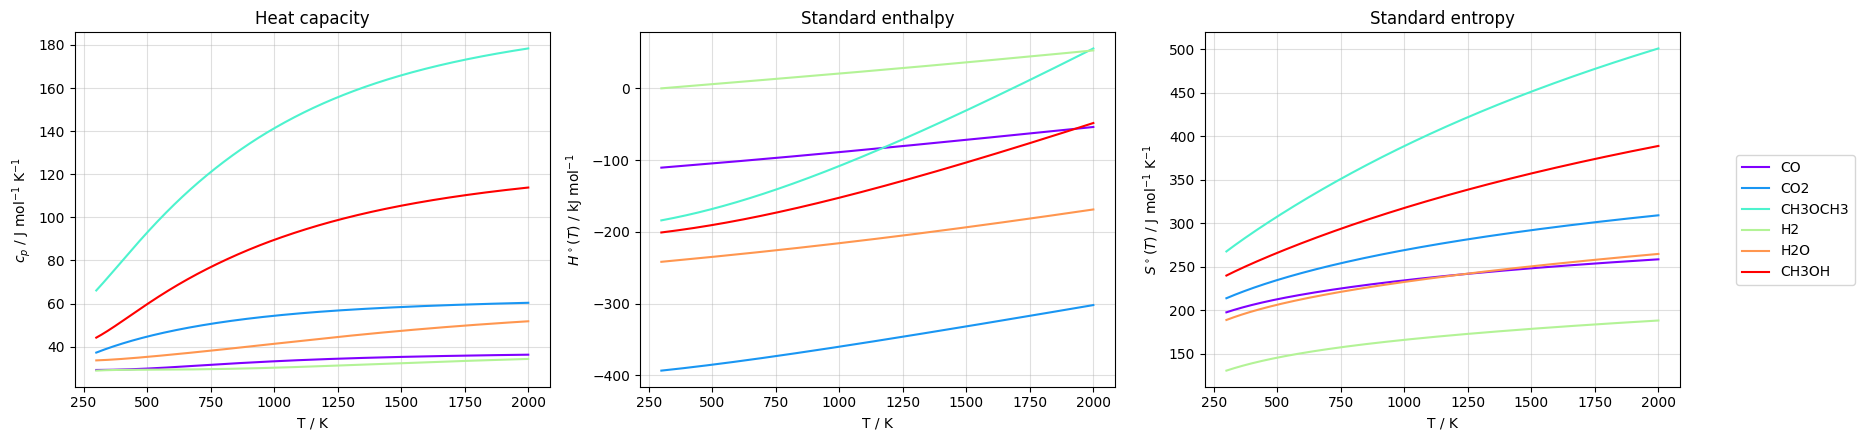

In [6]:
# Temperaturbereich
T_range = np.linspace(300, 2000, 1000)  # K, ggf. an deinen Gültigkeitsbereich anpassen
species_list = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']

# Daten sammeln
cp_data = np.full((len(species_list), len(T_range)), np.nan)
hf_data = np.full((len(species_list), len(T_range)), np.nan)
s_data  = np.full((len(species_list), len(T_range)), np.nan)

for i, sp in enumerate(species_list):
    for j, T in enumerate(T_range):
        try:
            cp_data[i, j] = cp_T(sp, T)
            hf_data[i, j] = hf_T(sp, T)
            s_data[i, j]  = s_T(sp, T)
        except ValueError:
            pass  # T außerhalb der NASA-Range → NaN bleibt

# Plot: 1×3 Layout
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Farben aus Rainbow-Colormap
colors = plt.cm.rainbow(np.linspace(0, 1, len(species_list)))

for i, sp in enumerate(species_list):
    axes[0].plot(T_range, cp_data[i],        label=sp, color=colors[i])
    axes[1].plot(T_range, hf_data[i] / 1000, label=sp, color=colors[i])  # → kJ/mol
    axes[2].plot(T_range, s_data[i],         label=sp, color=colors[i])

axes[0].set_xlabel('T / K')
axes[0].set_ylabel(r'$c_p$ / J mol$^{-1}$ K$^{-1}$')
axes[0].set_title('Heat capacity')

axes[1].set_xlabel('T / K')
axes[1].set_ylabel(r'$H^\circ(T)$ / kJ mol$^{-1}$')
axes[1].set_title('Standard enthalpy')

axes[2].set_xlabel('T / K')
axes[2].set_ylabel(r'$S^\circ(T)$ / J mol$^{-1}$ K$^{-1}$')
axes[2].set_title('Standard entropy')

for ax in axes:
    ax.grid(True, alpha=0.4)

# Einzige Legende rechts neben den Plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

## Calculating Reaction-enthalpy, -entropy and -gibbs energy

In [7]:
def reaction_enthalpy(reaction, T):
    """
    Calculate the reaction enthalpy (ΔH) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔH: Reaction enthalpy in J/mol (float).
    """
    delta_H = 0.0
    for species, coeff in reaction:
        hf = hf_T(species, T)
        delta_H += coeff * hf
    return delta_H

def reaction_entropy(reaction, T):
    """
    Calculate the reaction entropy (ΔS) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔS: Reaction entropy in J/(mol*K) (float).
    """
    delta_S = 0.0
    for species, coeff in reaction:
        S = s_T(species, T)
        delta_S += coeff * S
    return delta_S

def reaction_gibbs_free_energy(reaction, T):
    """
    Calculate the reaction Gibbs free energy (ΔG) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔG: Reaction Gibbs free energy in J/mol (float).
    """
    delta_H = reaction_enthalpy(reaction, T)
    delta_S = reaction_entropy(reaction, T)
    delta_G = delta_H - T * delta_S
    return delta_G

def eq_const_p(reaction, T):
    """
    Calculate the equilibrium constant (K) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - K: Equilibrium constant (dimensionless).
    """
    delta_G = reaction_gibbs_free_energy(reaction, T)
    K = np.exp((-delta_G )/ (R * T))
    return K

# k_x = K_p * p^Δν

def stoich_coeff_change(reaction):
    """Change in molar stoichiometric coefficient Δν = Σ vi."""
    dnu = 0
    for species, coeff in reaction:
        dnu += coeff
    return dnu

def eq_const_x(reaction, T, p):
    """
    Calculate the equilibrium constant (K_x) at a given temperature T and pressure p for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    - p: Pressure in bar (float).
    
    Returns:
    - K_x: Equilibrium constant (dimensionless).
    """
    K_p = eq_const_p(reaction, T)
    dnu = stoich_coeff_change(reaction)
    K_x = K_p * (p ** (-dnu))
    return K_x


print("\n--- Thermodynamic Properties Calculation ---")
# Validation values for Temperatures 298,15 K, 500 K, 1000 K, printed as a table for readability

print(f"{'Reaction':<10} {'T (K)':<10} {'ΔH (kJ/mol)':<20} {'ΔS (J/mol*K)':<20} {'ΔG (kJ/mol)':<20} {'K_p':<15} {'K_x (p=1 bar)':<20}")
reaction_names = ['R1', 'R2', 'R4', 'R3']  # Adjusted order for independence
for T in validation_temperatures:
    print("-" * 120)
    for i in range(4):
        r_reaction = reaction_tuples[i]
        r_name = reaction_names[i]
        delta_H = reaction_enthalpy(r_reaction, T) / 1000  # Convert to kJ/mol
        delta_S = reaction_entropy(r_reaction, T)
        delta_G = reaction_gibbs_free_energy(r_reaction, T) / 1000  # Convert to kJ/mol
        K_p = eq_const_p(r_reaction, T)
        K_x = eq_const_x(r_reaction, T, p=1)  # Assuming p=1 bar for K_x
        print(f"{r_name:<10} {T:<10.2f} {delta_H:<20.2f} {delta_S:<20.2f} {delta_G:<20.2f} {K_p:<15.2e} {K_x:<20.2e}")


--- Thermodynamic Properties Calculation ---
Reaction   T (K)      ΔH (kJ/mol)          ΔS (J/mol*K)         ΔG (kJ/mol)          K_p             K_x (p=1 bar)       
------------------------------------------------------------------------------------------------------------------------
R1         298.15     -49.25               -177.18              3.57                 2.37e-01        2.37e-01            
R2         298.15     -90.40               -219.20              -25.05               2.44e+04        2.44e+04            
R4         298.15     -24.05               -23.41               -17.08               9.81e+02        9.81e+02            
R3         298.15     41.15                42.02                28.62                9.68e-06        9.68e-06            
------------------------------------------------------------------------------------------------------------------------
R1         500.00     -57.86               -199.42              41.85                4.24e-05        4

# Some thermodynamical data from https://doi.org/10.1021/acs.iecr.6b00815 and https://doi.org/10.1021/je00049a015 for checking our implementation of the equations above

## Literature Reference Values for Equilibrium Constants

### R1, R2, R3 — Source: Graaf & Winkelman (2016)
Graaf, G.H.; Winkelman, J.G.M. *Ind. Eng. Chem. Res.* **2016**, 55, 5854–5864.
DOI: 10.1021/acs.iecr.6b00815

Values from fitted correlations Eq. (8) (R2), Eq. (7) (R3), and Kp°(R1) = Kp°(R2) · Kp°(R3).
Only K_p° is reported; ΔrH°, ΔrS°, ΔrG° to be derived by the user.

| Reaction | T (°C) | T (K) | K_p° | Unit |
|----------|--------|-------|------|------|
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 200 | 473.15 | 7.66 × 10⁻⁵ | bar⁻² |
| R2: CO + 2H₂ ⇌ CH₃OH          | 200 | 473.15 | 1.77 × 10⁻²  | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 200 | 473.15 | 4.33 × 10⁻³  | —     |
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 250 | 523.15 | 1.89 × 10⁻⁵ | bar⁻² |
| R2: CO + 2H₂ ⇌ CH₃OH          | 250 | 523.15 | 1.66 × 10⁻³  | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 250 | 523.15 | 1.14 × 10⁻²  | —     |
| R2: CO + 2H₂ ⇌ CH₃OH          | 300 | 573.15 | 2.28 × 10⁻⁴  | bar⁻² |
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 300 | 573.15 | 5.72 × 10⁻⁶ | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 300 | 573.15 | 2.51 × 10⁻²  | —     |

### R4 — Source: Diep & Wainwright (1987)
Diep, B.T.; Wainwright, M.S. *J. Chem. Eng. Data* **1987**, 32, 330–333.
DOI: 10.1021/je00049a015

> **Note:** Temperatures reported here (498, 523, 573 K) are slightly different from the
> 473/523/573 K used for R1–R3 above. The 250 °C and 300 °C points are essentially
> identical (Δ = 0.15 K); only the first temperature differs (225 °C here vs. 200 °C above).

| Reaction | T (°C) | T (K) | K_p° | ΔG°r (kJ mol⁻¹) | Unit |
|----------|--------|-------|------|-----------------|------|
| R4: 2 CH₃OH ⇌ DME + H₂O | 225 | 498 | 12.948 | −10.604 | — |
| R4: 2 CH₃OH ⇌ DME + H₂O | 250 | 523 | 10.810 | −10.351 | — |
| R4: 2 CH₃OH ⇌ DME + H₂O | 300 | 573 |  7.318 |  −9.482 | — |




## Values differ, explanation from Claude (in german, sorry) below. Please discuss this in the report :)

https://claude.ai/share/51f3a95c-b91f-4825-b6d8-cbcd173ce7e9

## Visualizing the Values for $\Delta_{R}H(T)$, $\Delta_{R}S(T)$ and $\Delta_{R}G(T)$

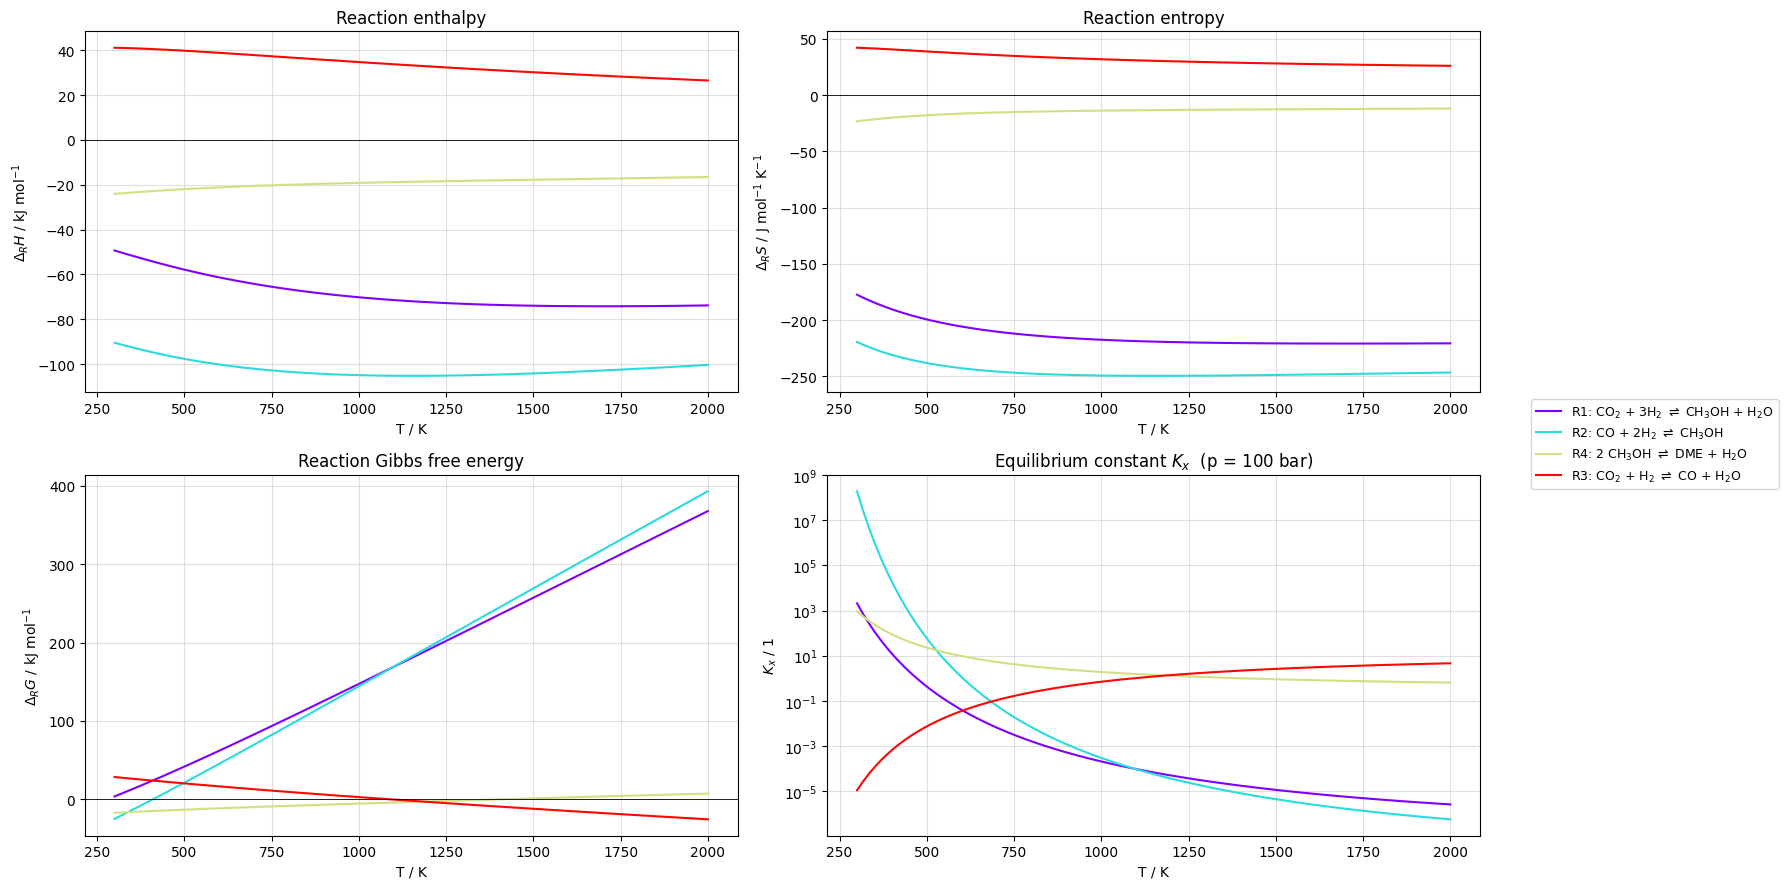

In [8]:
T_range = np.linspace(300, 2000, 100)

reaction_labels = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
    r'R4: 2 CH$_3$OH $\rightleftharpoons$ DME + H$_2$O',
    r'R3: CO$_2$ + H$_2$ $\rightleftharpoons$ CO + H$_2$O',
]

p_ref = 100  # bar — reference pressure for K_x calculation, can be adjusted as needed

# --- calculating data ---
dH_data = np.full((4, len(T_range)), np.nan)
dS_data = np.full((4, len(T_range)), np.nan)
dG_data = np.full((4, len(T_range)), np.nan)
Kx_data = np.full((4, len(T_range)), np.nan)

for r_idx in range(4):
    for j, T in enumerate(T_range):
        try:
            dH_data[r_idx, j] = reaction_enthalpy(reaction_tuples[r_idx], T)
            dS_data[r_idx, j] = reaction_entropy(reaction_tuples[r_idx], T)
            dG_data[r_idx, j] = reaction_gibbs_free_energy(reaction_tuples[r_idx], T)
            Kx_data[r_idx, j] = eq_const_x(reaction_tuples[r_idx], T, p_ref)
        except ValueError:
            pass

# --- 2×2 Plot with shared legend ---
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()  # [ΔH, ΔS, ΔG, K_x]

# defining colors for consistent legend, using rainbow colormap with 4 distinct colors for the 4 reactions
colors = plt.cm.rainbow(np.linspace(0, 0.99, 4))

for r_idx in range(4):
    axes[0].plot(T_range, dH_data[r_idx] / 1000, label=reaction_labels[r_idx], color=colors[r_idx])
    axes[1].plot(T_range, dS_data[r_idx],         label=reaction_labels[r_idx], color=colors[r_idx])
    axes[2].plot(T_range, dG_data[r_idx] / 1000,  label=reaction_labels[r_idx], color=colors[r_idx])
    axes[3].plot(T_range, Kx_data[r_idx],          label=reaction_labels[r_idx], color=colors[r_idx])

axes[0].set_ylabel(r'$\Delta_R H$ / kJ mol$^{-1}$')
axes[0].set_title('Reaction enthalpy')

axes[1].set_ylabel(r'$\Delta_R S$ / J mol$^{-1}$ K$^{-1}$')
axes[1].set_title('Reaction entropy')

axes[2].set_ylabel(r'$\Delta_R G$ / kJ mol$^{-1}$')
axes[2].set_title('Reaction Gibbs free energy')

axes[3].set_ylabel(r'$K_x$ / 1')
axes[3].set_title(f'Equilibrium constant $K_x$  (p = {p_ref} bar)')
axes[3].set_yscale('log')  # log-scale because of order of magnitude (R2 >> R3)

for ax in axes:
    ax.set_xlabel('T / K')
    ax.grid(True, alpha=0.4, which='both')
    ax.axhline(0, color='k', lw=0.6)

# single legend to the right of the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

## Getting $\xi$ from $K_x$

Above, we have calculated $K_x$, wich is for a single reaction defined as:

\begin{align}
    K_x &= \prod_i x_i^{\nu_i}
\end{align}

Our goal is, to calculate the reaction extend $\xi_i$ for all reaction j = {1,2,3,4}. This is done as follows:

The mass balance of component i in a reaction network, like the given one here, is:

\begin{align}
    \dot{n_{i,out}} &= \dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}
\end{align}

Therefor

\begin{align}
    \dot{n_{out}} &= \dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})
\end{align}

From this, we can write the molar fraction of species i as

\begin{align}
  x_{i,out} &= \frac{\dot n_{i,out}}{\dot n_{out}}=\frac{\dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}}{\dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})}
\end{align}

With this equation, we can calculate $x_i$ for an initual guess of $\xi$. Then we iteratively solve for the root of the equation

\begin{align}
    K_{x,j} - \prod_i x_{j,i}^{\nu_i} = 0
\end{align}

for our three Key reactions specified above. This gives us a numerical solution for the reaction extend $\xi$.

In [9]:
from scipy.optimize import root

def material_balance(reaction, xi, n_in, rc_ind):
    """
    Calculate the material balance for a given reaction, extent of reaction (xi), and initial moles (n_in).
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - xi: Extent of reactions (array of floats).
    - n_in: Initial moles of each species as an array [mol/h].
    - rc_ind: Indexes of the reactions for which to solve. (array of ints)
    
    Returns:
    - n_out: Final moles of each species after the reaction as an array [mol/h].
    """
    n_out = n_in.copy()                                     # Start with initial moles
    for i in range(min(len(rc_ind), len(reaction))):        # Loop through the reactions up to the specified index
        for j in range(len(n_in)):                          # Calculate the change in moles for each species based on the reaction coefficients and extent of reaction
            species, coeff = reaction[rc_ind[i]][j]
            n_out[j] = n_out[j] + (coeff * xi[i])           # Update the moles based on the extent of reaction and the stoichiometric coefficients
    return n_out                                            # Return the final moles after the reaction for the solver to compare and refine the guess of xi

def mole_fraction(n_out):
    """
    Calculate the mole fraction of each species given the final moles.
    
    Parameters:
    - n_out: Final moles of each species as an array [mol/h].
    
    Returns:
    - x: Mole fraction of each species as an array.
    """
    total_moles = np.sum(n_out)
    if total_moles == 0:
        return np.zeros_like(n_out)  # Avoid division by zero
    x = n_out / total_moles
    return x

def equilibrium_residuals(xi, reaction_list, n_in, T, p, reac_index):
    """
    Residuals of the equilibrium conditions in direct (non-log) form:
    res_k = K_x * prod(x_educt^|nu|) - prod(x_prod^nu) = 0
    
    Parameters
    ----------
    xi           : array, shape (n_reactions,)
    reaction_list: list of reactions in tuple form
    n_in         : array, shape (n_species,)
    T            : float - temperature [K]
    p            : float - pressure [bar]
    reac_index   : list of int
    
    Returns
    -------
    res : array, shape (n_reactions,)
    """
    n_out = material_balance(reaction_list, xi, n_in, reac_index)
    total = np.sum(n_out)
    x = n_out / total

    res = np.zeros(len(reac_index))
    for k, j in enumerate(reac_index):
        K_x = eq_const_x(reaction_list[j], T, p)
        educt_term   = 1.0
        product_term = 1.0
        for i, (species, coeff) in enumerate(reaction_list[j]):
            if coeff < 0:
                educt_term   *= x[i] ** abs(coeff)
            elif coeff > 0:
                product_term *= x[i] ** coeff
        res[k] = K_x * educt_term - product_term

    return res

#--- Calculating a meaningful starting guess from the given starting conditions, to help the solver start ---
def make_initial_guess(n_in, reac_index, reaction_list, fraction=0.01):
    """
    Generate a physically motivated initial guess for xi based on the limiting
    reactant of each reaction. Uses a small fraction of the limiting reactant
    to ensure all species are nonzero at the start.
    
    Parameters
    ----------
    n_in         : array - inlet molar flow [mol/h]
    reac_index   : list of int - reaction indices to solve
    reaction_list: list of reactions in tuple form
    fraction     : float - fraction of limiting reactant to use as guess
    
    Returns
    -------
    xi_init : array, shape (n_reactions,)
    """
    xi_init = np.zeros(len(reac_index))
    for k, j in enumerate(reac_index):
        limiting = np.inf
        for i, (species, coeff) in enumerate(reaction_list[j]):
            if coeff < 0:  # reactant
                available = n_in[i] / abs(coeff)
                if available > 0:
                    limiting = min(limiting, available)
        if np.isinf(limiting):
            limiting = 0.01  # fallback if no reactant present
        xi_init[k] = fraction * limiting
    return xi_init


def root_solver(reaction_list, xi_init, n_in, T, p, reac_index):
    """
    Solves for equilibrium xi using scipy.optimize.root (method: hybr).

    Parameters
    ----------
    reaction_list: list of reactions in tuple form
    xi_init      : array - primary initial guess for xi [mol/h]
    n_in         : array - inlet molar flow [mol/h]
    T            : float - temperature [K]
    p            : float - pressure [bar]
    reac_index   : list of int - indices of reactions to solve

    Returns
    -------
    xi  : array  - equilibrium extent of reaction
    sol : OptimizeResult - full solver result
    """
    if xi_init is None:
        xi_init = make_initial_guess(n_in, reac_index, reaction_list)

    sol = root(
        equilibrium_residuals,
        xi_init,
        args=(reaction_list, n_in, T, p, reac_index),
        method='hybr',
        tol=1e-6
    )
    return sol.x, sol


for k, n_in_test in enumerate([
    np.array([1.0, 1.0, 0.0, 2.0, 0.0, 0.0]),
    np.array([2.0, 1.0, 1.0, 0.0, 2.0, 1.0]),
    np.array([0.0, 0.0, 0.0, 2.0, 1.0, 2.0]),
    np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0]),
    np.array([2.0, 1.0, 0.0, 1.0, 0.0, 0.0]),
]):
    xi, sol = root_solver(reaction_tuples, None, n_in_test, 500, 1, [0, 1, 2])
    n_out = material_balance(reaction_tuples, xi, n_in_test, [0, 1, 2])
    print(f"Test {k+1}: xi = {np.round(xi,4)}, success = {sol.success}, n_out >= 0: {np.all(n_out >= -1e-9)}")

Test 1: xi = [ 0.011  -0.003   0.0033], success = True, n_out >= 0: True
Test 2: xi = [  1.7402 -10.2055  -3.7469], success = True, n_out >= 0: False
Test 3: xi = [ 0.299  -4.8899 -1.3038], success = True, n_out >= 0: False
Test 4: xi = [ 1.6418 -7.9167 -2.6481], success = True, n_out >= 0: False
Test 5: xi = [0.0005 0.0065 0.0031], success = True, n_out >= 0: True


# Visualizing the reaction etxend $\xi$ as a function of T, p and inlet concentration

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- Test cases ---
test_cases = [
    ("Case 0: 18 H2 / 6 CO2",                      np.array([0.0, 6.0, 0.0, 18.0, 0.0, 0.0])),
    ("Case 1: 12 H2 / 4 CO2",                      np.array([0.0, 4.0, 0.0, 12.0, 0.0, 0.0])),
    ("Case 2: 6 H2 / 2 CO2",                       np.array([0.0, 2.0, 0.0,  6.0, 0.0, 0.0])),
    ("Case 3: 6 H2 / 2 CO2 / 1 CO / 1 H2O",       np.array([1.0, 2.0, 0.0,  6.0, 1.0, 0.0])),
    ("Case 4: 4 H2 / 2 CO2 / 1 CO / 1 MeOH",      np.array([1.0, 2.0, 0.0,  4.0, 0.0, 1.0])),
    ("Case 5: 1 of all species",                   np.array([1.0, 1.0, 1.0,  1.0, 1.0, 1.0])),
]

reaction_indices      = [0, 1, 2]
reaction_labels_short = ['R1: CO$_2$ + 3H$_2$ → CH$_3$OH + H$_2$O',
                         'R2: CO + 2H$_2$ → CH$_3$OH',
                         'R4: 2 CH$_3$OH → DME + H$_2$O']

def safe_solve(n_in, T, p, xi_init=None, xi_prev=None):
    """
    Robust wrapper around root_solver.
    - If xi_init is None, uses make_initial_guess() based on the feed composition.
    - If xi_prev is provided, retries with xi_prev as guess if the first attempt fails.
    - Returns NaN array if solver fails or produces unphysical results.
    """
    # Use feed-based guess if no initial guess is provided
    if xi_init is None:
        xi_init = make_initial_guess(n_in, reaction_indices, reaction_tuples)

    try:
        xi, sol = root_solver(reaction_tuples, list(xi_init), n_in, T, p, reaction_indices)

        # If solver failed and we have a previous solution, retry with xi_prev
        if not sol.success and xi_prev is not None:
            xi, sol = root_solver(reaction_tuples, list(xi_prev), n_in, T, p, reaction_indices)

        if not sol.success:
            return np.full(3, np.nan)

        # Check physical validity: no negative molar flows
        n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
        tol = 1e-4 * max(np.sum(n_in), 1.0)
        if np.any(n_out < -tol):
            return np.full(3, np.nan)

        return xi

    except Exception:
        return np.full(3, np.nan)

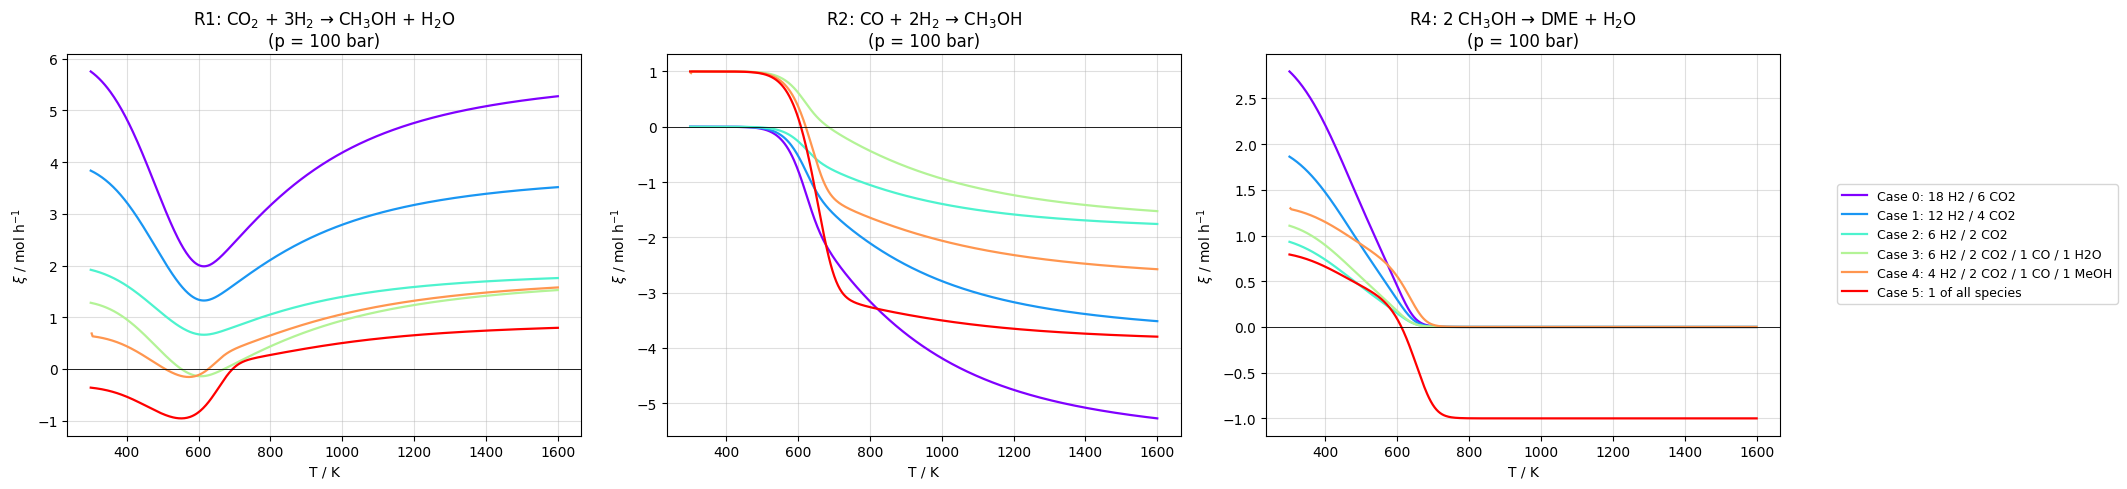

In [11]:
# ====================== ξ vs T (for a fixed p) ======================
T_range = np.linspace(300, 1600, 500)
p_fixed = 100

xi_T = np.full((len(test_cases), 3, len(T_range)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    # Pass 1: low-to-high T
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for ti, T in enumerate(T_range):
        xi = safe_solve(n_in, T, p_fixed, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_T[ci, :, ti] = xi
            xi_prev = xi

    # Pass 2: high-to-low T — fills gaps left by pass 1
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for ti, T in enumerate(reversed(T_range)):
        real_ti = len(T_range) - 1 - ti
        if not np.any(np.isnan(xi_T[ci, :, real_ti])):
            xi_prev = xi_T[ci, :, real_ti]
            continue
        xi = safe_solve(n_in, T, p_fixed, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_T[ci, :, real_ti] = xi
            xi_prev = xi

colors = plt.cm.rainbow(np.linspace(0, 1, len(test_cases)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r_idx in range(3):
    for ci, (name, n_in) in enumerate(test_cases):
        axes[r_idx].plot(T_range, xi_T[ci, r_idx, :], label=name, lw=1.6, color=colors[ci])
    axes[r_idx].set_xlabel('T / K')
    axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
    axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(p = {p_fixed} bar)')
    axes[r_idx].grid(True, alpha=0.4)
    axes[r_idx].axhline(0, color='k', lw=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

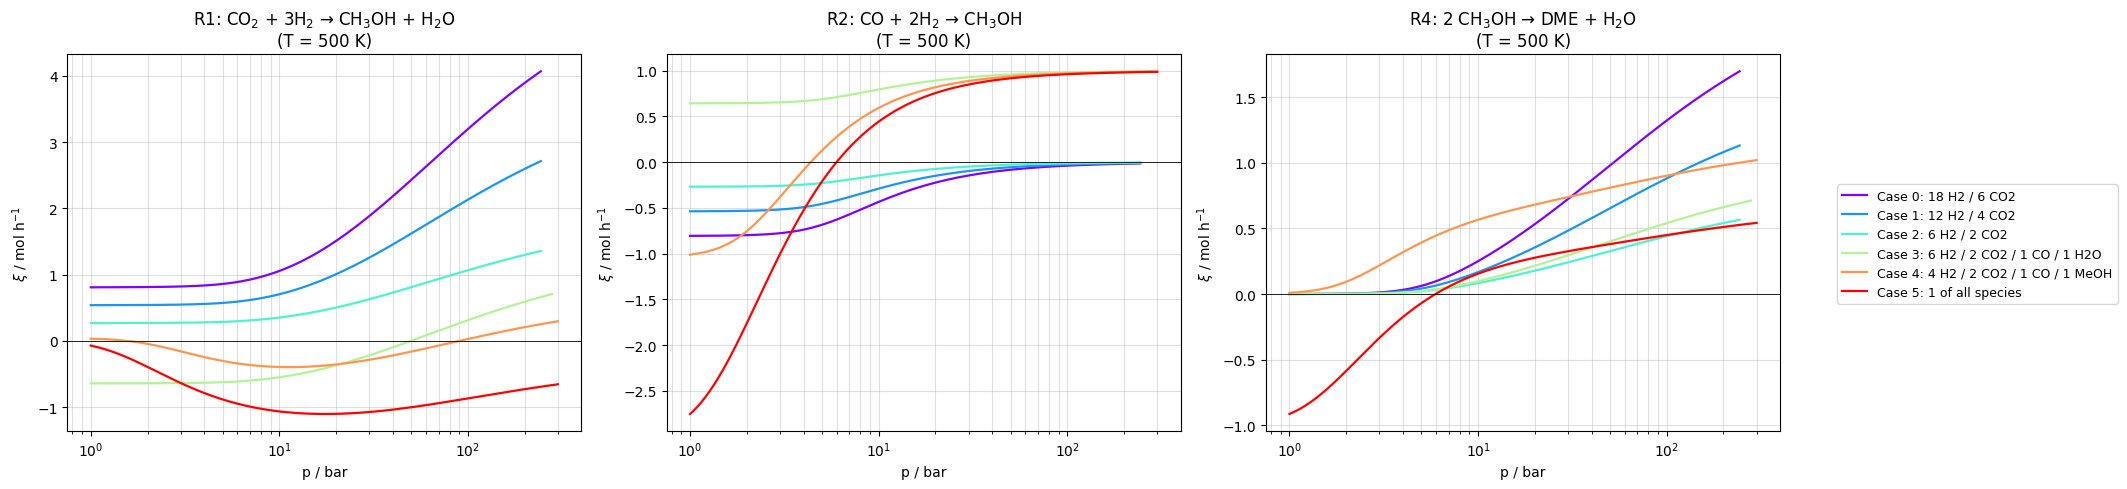

In [12]:
# ====================== ξ vs p (for a fixed T) ======================
p_critical_region = np.linspace(1, 10, 300)
p_smooth_high = np.logspace(np.log10(10), np.log10(300), 50)
p_range = np.concatenate([p_critical_region[:-1], p_smooth_high])
T_fixed = 500

xi_p = np.full((len(test_cases), 3, len(p_range)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    # Solve high-to-low: warm-start from high pressure where solver is stable
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    
    for pi, p in enumerate(reversed(p_range)):
        xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_prev = xi
            # Store at correct index (reversed)
            xi_p[ci, :, len(p_range) - 1 - pi] = xi

# --- Plotting (unchanged) ---
colors = plt.cm.rainbow(np.linspace(0, 1, len(test_cases)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r_idx in range(3):
    for ci, (name, n_in) in enumerate(test_cases):
        axes[r_idx].plot(p_range, xi_p[ci, r_idx, :], label=name, lw=1.6, color=colors[ci])
    axes[r_idx].set_xlabel('p / bar')
    axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
    axes[r_idx].set_xscale('log')
    axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_fixed} K)')
    axes[r_idx].grid(True, alpha=0.4, which='both')
    axes[r_idx].axhline(0, color='k', lw=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

## Old plot for p, showing that the direction from which the solver begins makes a significant difference in the solution. 
We get values for low pressure when we start from high pressure to low, 
but we do not get a solution if we start from low pressure. This is because the solver only returns 
values other than NaN if the solution is physically sensible. We pass the solution from the last 
attempt as the initial guess for the next attempt. As long as the previous attempt did not converge, 
the current attempt therefore only has the feed-based initial guess, which performs poorly at low 
pressures, leading to NaN values (hence the plot below). If we start from high pressure, we get 
sensible solutions from the beginning, and the solver passes good initial guesses at every step, 
leading to sensible solutions even at low pressures.

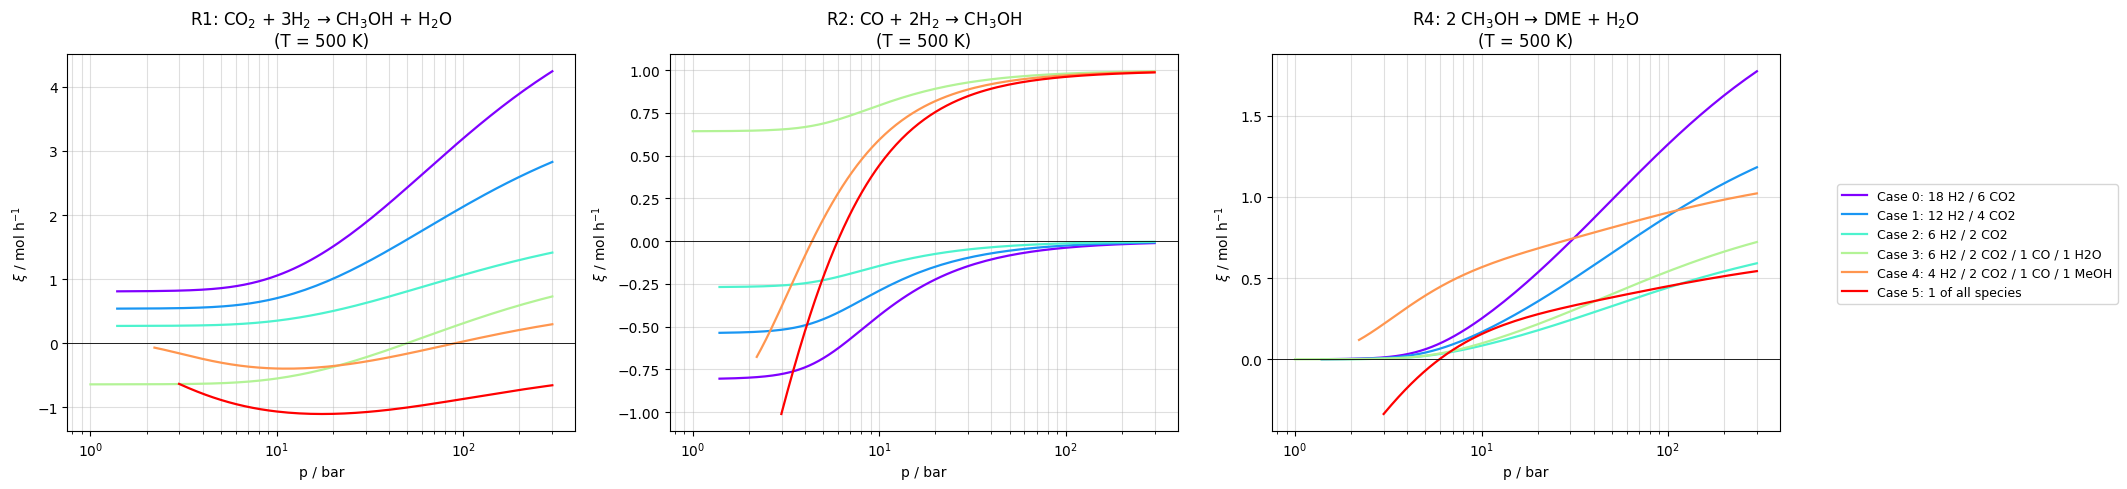

In [13]:
# ====================== ξ vs p (for a fixed T) ======================
# p_range  = np.logspace(0, np.log10(300), 100)  # 1 ... 300 bar, log-scaled
p_critical_region = np.linspace(1, 10, 300)   # ← Bereich mit Struktur, 300 Punkte
# p_smooth_low  = np.logspace(0, np.log10(5), 30)    # 1-5 bar, 30 Punkte
p_smooth_high = np.logspace(np.log10(10), np.log10(300), 50)  # 20-300 bar, 50 Punkte

p_range = np.concatenate([p_critical_region[:-1], p_smooth_high])
T_fixed  = 500  # K — typical for dme synthesis, can be changed to your needs

xi_p = np.full((len(test_cases), 3, len(p_range)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for pi, p in enumerate(p_range):
        xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_p[ci, :, pi] = xi
            xi_prev = xi

# Define colors from rainbow colormap for consistent appearance across all plots
colors = plt.cm.rainbow(np.linspace(0, 1, len(test_cases)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r_idx in range(3):
    for ci, (name, n_in) in enumerate(test_cases):
        axes[r_idx].plot(p_range, xi_p[ci, r_idx, :], label=name, lw=1.6, color=colors[ci])
    axes[r_idx].set_xlabel('p / bar')
    axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
    axes[r_idx].set_xscale('log')
    axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_fixed} K)')
    axes[r_idx].grid(True, alpha=0.4, which='both')
    axes[r_idx].axhline(0, color='k', lw=0.6)

# Single legend positioned to the right of all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

## Modular 3D-plotting

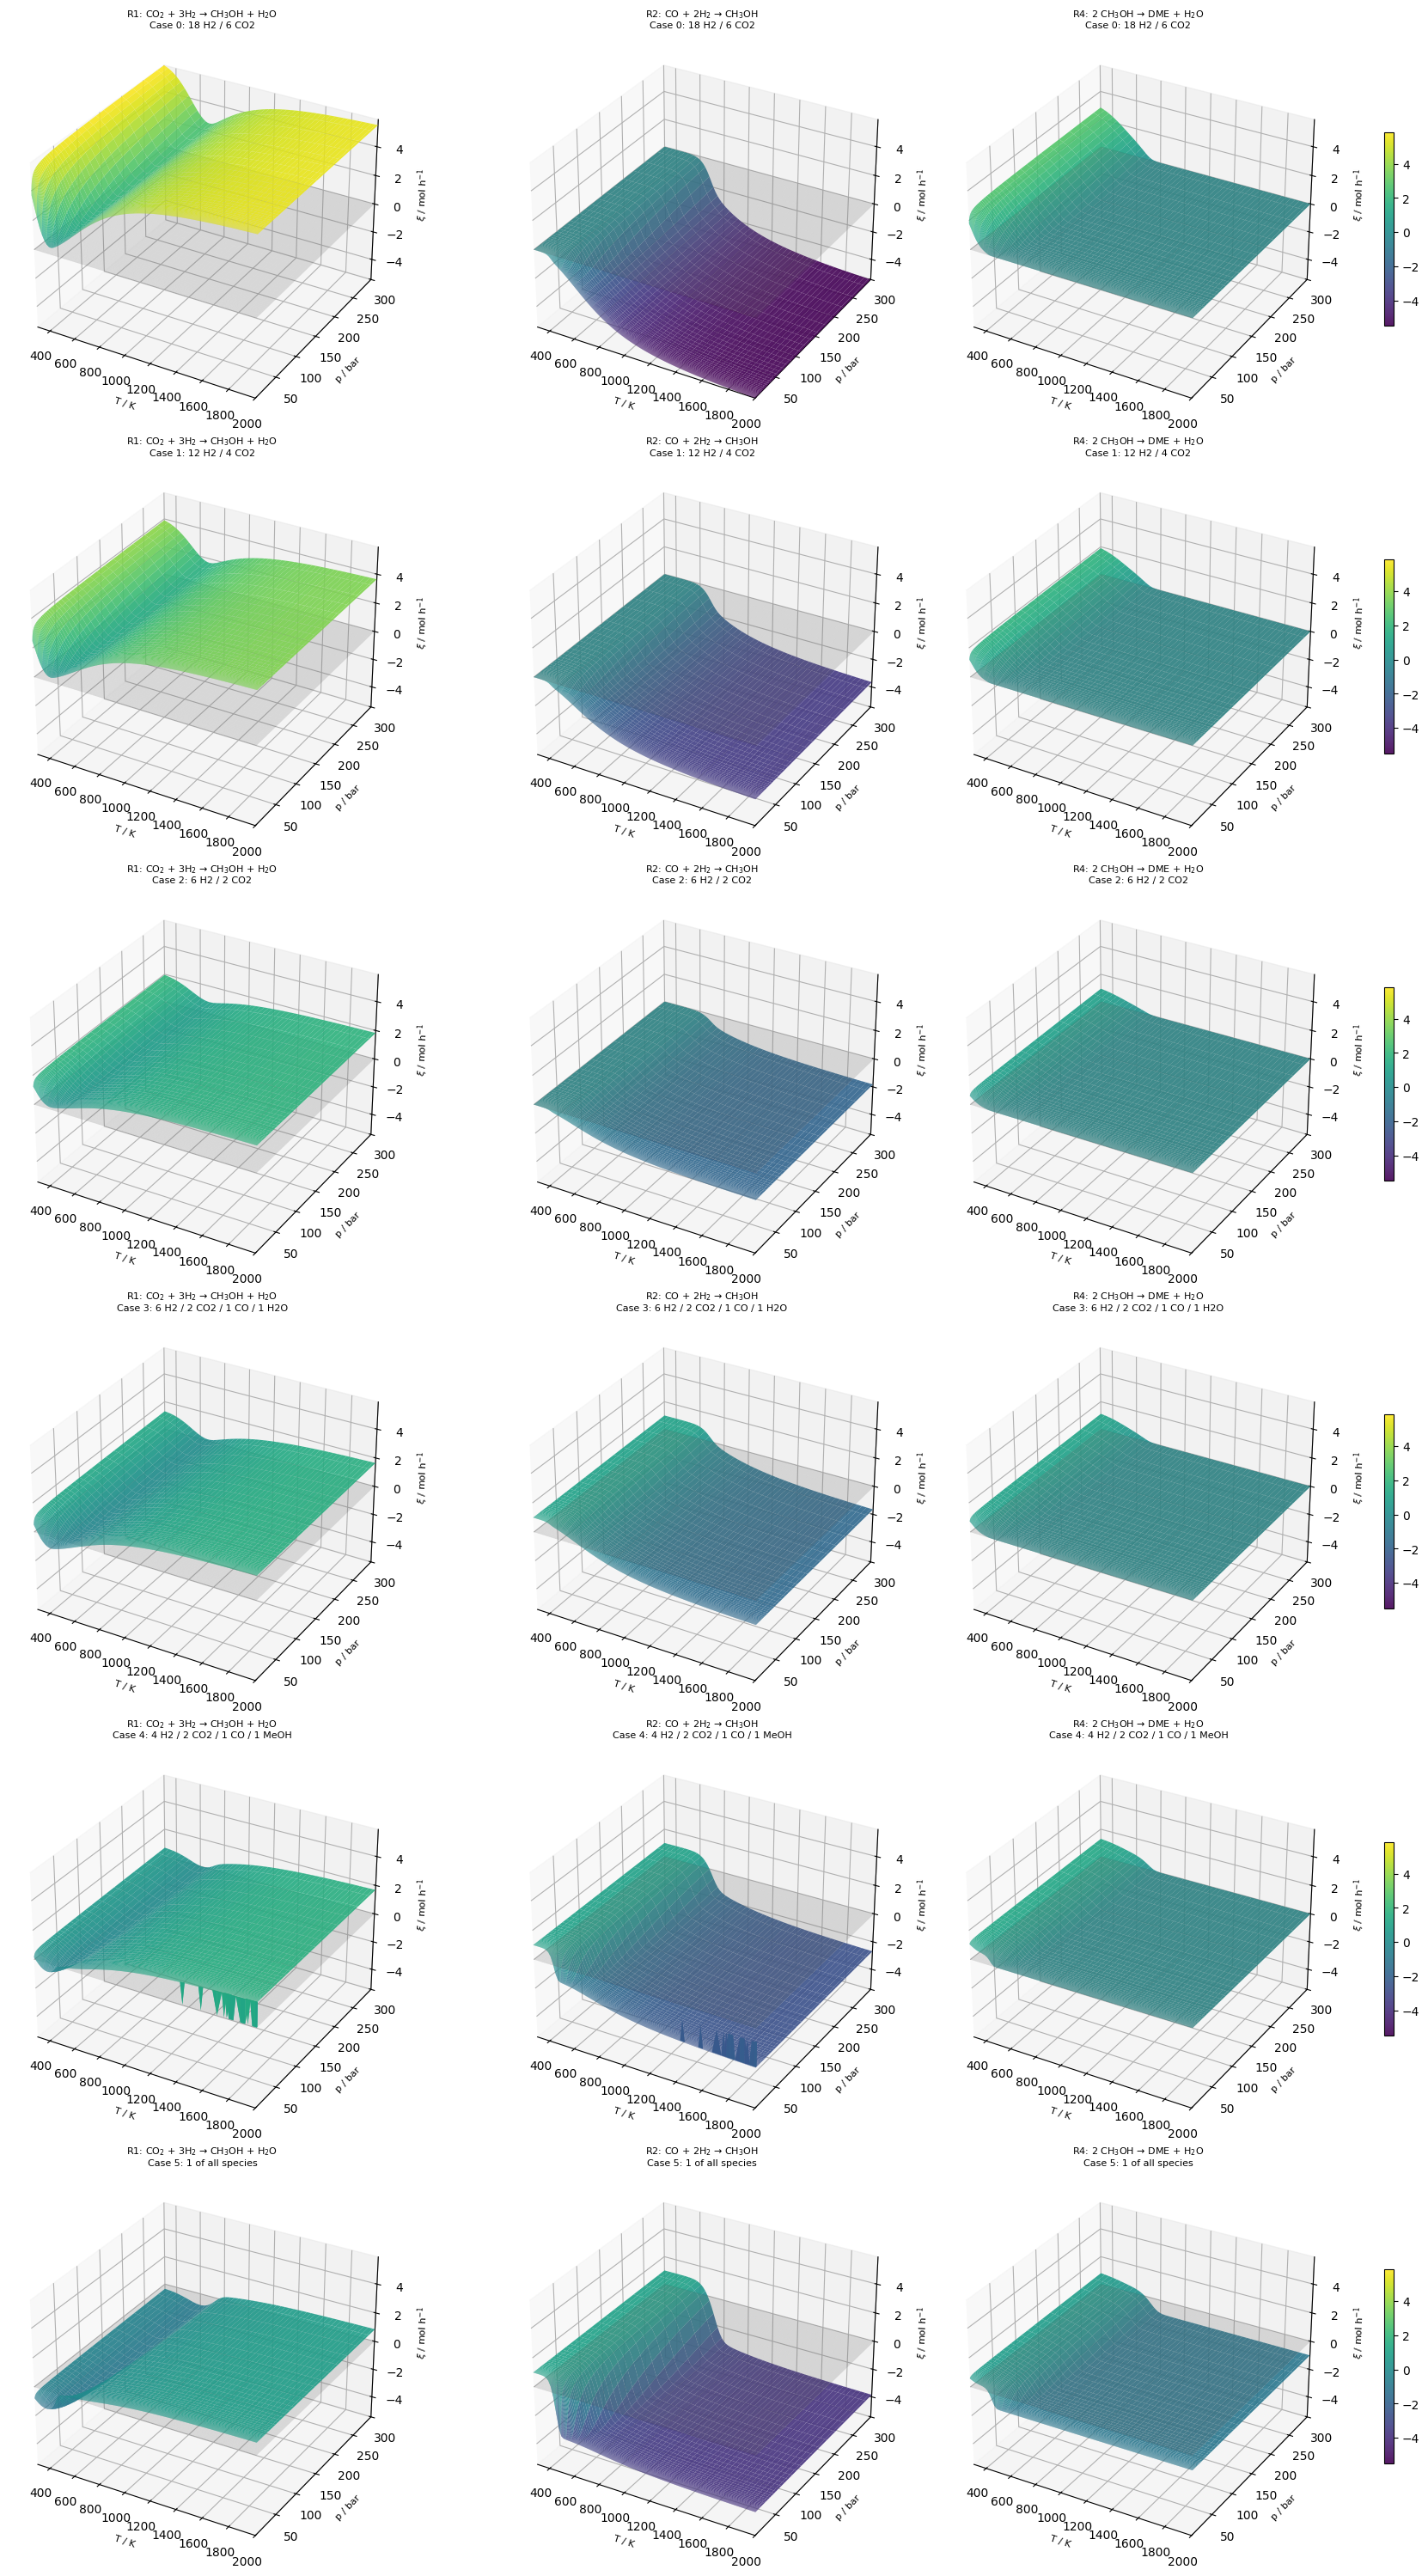

In [14]:
# ====================== 3D-Surface: ξ(T,p) for all test cases ======================

T_3d = np.linspace(300, 2000, 100)
p_3d = np.logspace(0, np.log10(300), 100)
T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)

n_cases = len(test_cases)

# --- Compute xi_TP for all cases ---
xi_TP_all = np.full((n_cases, 3, len(p_3d), len(T_3d)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    # Pass 1 & 2: high-to-low p, both T directions
    for pi, p in enumerate(reversed(p_3d)):
        real_pi = len(p_3d) - 1 - pi

        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(reversed(T_3d)):
            real_ti = len(T_3d) - 1 - ti
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, real_pi, real_ti] = xi

        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(T_3d):
            if not np.any(np.isnan(xi_TP_all[ci, :, real_pi, ti])):
                xi_prev = xi_TP_all[ci, :, real_pi, ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, real_pi, ti] = xi

    # Pass 3: low-to-high p, both T directions
    for pi, p in enumerate(p_3d):
        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(T_3d):
            if not np.any(np.isnan(xi_TP_all[ci, :, pi, ti])):
                xi_prev = xi_TP_all[ci, :, pi, ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, pi, ti] = xi

        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(reversed(T_3d)):
            real_ti = len(T_3d) - 1 - ti
            if not np.any(np.isnan(xi_TP_all[ci, :, pi, real_ti])):
                xi_prev = xi_TP_all[ci, :, pi, real_ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, pi, real_ti] = xi

# --- Global color scale across all cases and reactions ---
vmin = np.nanmin(xi_TP_all)
vmax = np.nanmax(xi_TP_all)
zmin = vmin
zmax = vmax

z_plane = np.zeros_like(T_mesh)

# --- Plot: rows = cases, cols = reactions ---
fig, axes = plt.subplots(
    n_cases, 3,
    figsize=(18, 5 * n_cases),
    subplot_kw={'projection': '3d'}
)

# Ensure axes is always 2D array even for a single case
if n_cases == 1:
    axes = axes[np.newaxis, :]

for ci, (name, n_in) in enumerate(test_cases):
    for r_idx in range(3):
        ax = axes[ci, r_idx]
        surf = ax.plot_surface(
            T_mesh, p_mesh, xi_TP_all[ci, r_idx],
            cmap='viridis', alpha=0.9, edgecolor='none',
            vmin=vmin, vmax=vmax
        )
        ax.plot_surface(
            T_mesh, p_mesh, z_plane,
            alpha=0.2, color='gray', edgecolor='none'
        )
        ax.set_xlabel('T / K', fontsize=8)
        ax.set_ylabel('p / bar', fontsize=8)
        ax.set_zlabel(r'$\xi$ / mol h$^{-1}$', fontsize=8)
        ax.set_title(f'{reaction_labels_short[r_idx]}\n{name}', fontsize=8)
        ax.set_xlim([T_3d.min(), T_3d.max()])
        ax.set_ylim([p_3d.min(), p_3d.max()])
        ax.set_zlim([zmin, zmax])

        # Colorbar only on last column
        if r_idx == 2:
            fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

plt.tight_layout()
plt.show()

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ====================== 3D-Surface: ξ(T,p) for a single test case (Interactive) ======================
SELECTED_CASE = 2   # ← Index 0..4 respectively for Reaction Cases 1..5

name, n_in = test_cases[SELECTED_CASE]

# Grid (coarser than 2D plots to keep computation time reasonable)
T_3d = np.linspace(300, 2000, 100)
p_3d = np.logspace(0, np.log10(300), 100)
T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)

xi_TP = np.full((3, len(p_3d), len(T_3d)), np.nan)

for pi, p in enumerate(reversed(p_3d)):
    real_pi = len(p_3d) - 1 - pi

    # Pass 1: high-to-low T
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for ti, T in enumerate(reversed(T_3d)):
        real_ti = len(T_3d) - 1 - ti
        xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_prev = xi
            xi_TP[:, real_pi, real_ti] = xi

    # Pass 2: low-to-high T — fills gaps left by pass 1
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for ti, T in enumerate(T_3d):
        if not np.any(np.isnan(xi_TP[:, real_pi, ti])):
            xi_prev = xi_TP[:, real_pi, ti]  # use already computed value as warm-start
            continue
        xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_prev = xi
            xi_TP[:, real_pi, ti] = xi

# Determine global min and max across all three reactions for consistent color mapping
vmin = np.nanmin(xi_TP)
vmax = np.nanmax(xi_TP)

# Determine global axis limits for consistent scaling
zmin = np.nanmin(xi_TP)
zmax = np.nanmax(xi_TP)

# Create subplots with 3D surface plots
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=(f'{'R1'}<br>{name}',
                    f'{'R2'}<br>{name}',
                    f'{'R4'}<br>{name}')
)

for r_idx in range(3):
    # Add main surface plot
    fig.add_trace(
        go.Surface(
            x=T_mesh[0],
            y=p_mesh[:, 0],
            z=xi_TP[r_idx],
            colorscale='Viridis',
            cmin=vmin,
            cmax=vmax,
            showscale=(r_idx == 2),  # Only show colorbar on last plot
            colorbar=dict(x=1.02, len=0.7) if r_idx == 2 else None,
            name='ξ surface',
            hovertemplate='T: %{x:.0f} K<br>p: %{y:.1f} bar<br>ξ: %{z:.2f} mol/h<extra></extra>'
        ),
        row=1, col=r_idx + 1
    )

# Update axes labels and ranges
for col in range(1, 4):
    fig.update_scenes(
        xaxis=dict(title='T / K', range=[T_3d.min(), T_3d.max()]),
        yaxis=dict(title='p / bar', range=[p_3d.min(), p_3d.max()]),
        zaxis=dict(title='ξ / mol h⁻¹', range=[zmin, zmax]),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.3)),
        row=1, col=col
    )

fig.update_layout(
    title_text=f'3D Surface: ξ(T,p) for {name}',
    width=1800,
    height=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ====================== Interactive 3D-Surface: ξ(T,p) for all test cases ======================

T_3d = np.linspace(300, 2000, 50)
p_3d = np.logspace(0, np.log10(300), 50)
T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)

n_cases = len(test_cases)

# --- Compute xi_TP for all cases ---
xi_TP_all = np.full((n_cases, 3, len(p_3d), len(T_3d)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for pi, p in enumerate(reversed(p_3d)):
        real_pi = len(p_3d) - 1 - pi

        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(reversed(T_3d)):
            real_ti = len(T_3d) - 1 - ti
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, real_pi, real_ti] = xi

        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(T_3d):
            if not np.any(np.isnan(xi_TP_all[ci, :, real_pi, ti])):
                xi_prev = xi_TP_all[ci, :, real_pi, ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, real_pi, ti] = xi

    for pi, p in enumerate(p_3d):
        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(T_3d):
            if not np.any(np.isnan(xi_TP_all[ci, :, pi, ti])):
                xi_prev = xi_TP_all[ci, :, pi, ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, pi, ti] = xi

        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(reversed(T_3d)):
            real_ti = len(T_3d) - 1 - ti
            if not np.any(np.isnan(xi_TP_all[ci, :, pi, real_ti])):
                xi_prev = xi_TP_all[ci, :, pi, real_ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_prev = xi
                xi_TP_all[ci, :, pi, real_ti] = xi

# --- Global color scale ---
vmin = np.nanmin(xi_TP_all)
vmax = np.nanmax(xi_TP_all)
zmin = vmin
zmax = vmax

# --- Plot: one figure per case, cols = reactions ---
for ci, (name, n_in) in enumerate(test_cases):
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
        subplot_titles=(f'{'R1'}<br>{name}',
                        f'{'R2'}<br>{name}',
                        f'{'R4'}<br>{name}')
    )

    for r_idx in range(3):
        fig.add_trace(
            go.Surface(
                x=T_mesh[0],
                y=p_mesh[:, 0],
                z=xi_TP_all[ci, r_idx],
                colorscale='Viridis',
                cmin=vmin,
                cmax=vmax,
                showscale=(r_idx == 2),
                colorbar=dict(x=1.02, len=0.7) if r_idx == 2 else None,
                name='ξ surface',
                hovertemplate='T: %{x:.0f} K<br>p: %{y:.1f} bar<br>ξ: %{z:.2f} mol/h<extra></extra>'
            ),
            row=1, col=r_idx + 1
        )

    for col in range(1, 4):
        fig.update_scenes(
            xaxis=dict(title='T / K', range=[T_3d.min(), T_3d.max()]),
            yaxis=dict(title='p / bar', range=[p_3d.min(), p_3d.max()]),
            zaxis=dict(title='ξ / mol h⁻¹', range=[zmin, zmax]),
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.3)),
            row=1, col=col
        )

    fig.update_layout(
        title_text=f'3D Surface: ξ(T,p) — {name}',
        width=1800,
        height=700,
        showlegend=False,
        hovermode='closest'
    )

    fig.show()

# Yield

In [17]:
def dme_yield(n_in, n_out):
    """
    Calculate the DME yield with respect to CO2 feed.
    Based on the overall reaction: 2 CO2 + 6 H2 → DME + 3 H2O
    
    Y_DME = (nu_CO2 / nu_DME) * (n_DME_out - n_DME_in) / n_CO2_in
          = (2 / 1) * (n_DME_out - n_DME_in) / n_CO2_in
    
    Parameters
    ----------
    n_in  : array - inlet molar flow [mol/h],  order: [CO, CO2, DME, H2, H2O, CH3OH]
    n_out : array - outlet molar flow [mol/h], order: [CO, CO2, DME, H2, H2O, CH3OH]
    
    Returns
    -------
    Y_DME : float - DME yield [-]
    """
    nu_CO2 = 2.0
    nu_DME = 1.0

    n_CO2_in  = n_in[1]   # index 1 = CO2
    n_DME_in  = n_in[2]   # index 2 = DME
    n_DME_out = n_out[2]  # index 2 = DME

    if n_CO2_in <= 0:
        return np.nan  # undefined if no CO2 in feed

    return (nu_CO2 / nu_DME) * (n_DME_out - n_DME_in) / n_CO2_in

In [18]:
# --- Test: DME yield for Case 0 at T=500K, p=100bar ---
name, n_in = test_cases[0]
xi, sol = root_solver(reaction_tuples, list(make_initial_guess(n_in, reaction_indices, reaction_tuples)), n_in, 500, 100, reaction_indices)
n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)

Y = dme_yield(n_in, n_out)
print(f"{name}")
print(f"  n_in:  {n_in}")
print(f"  n_out: {np.round(n_out, 4)}")
print(f"  Y_DME: {Y:.4f}")

Case 0: 18 H2 / 6 CO2
  n_in:  [ 0.  6.  0. 18.  0.  0.]
  n_out: [0.0384 2.8024 1.3227 8.484  4.5203 0.5138]
  Y_DME: 0.4409


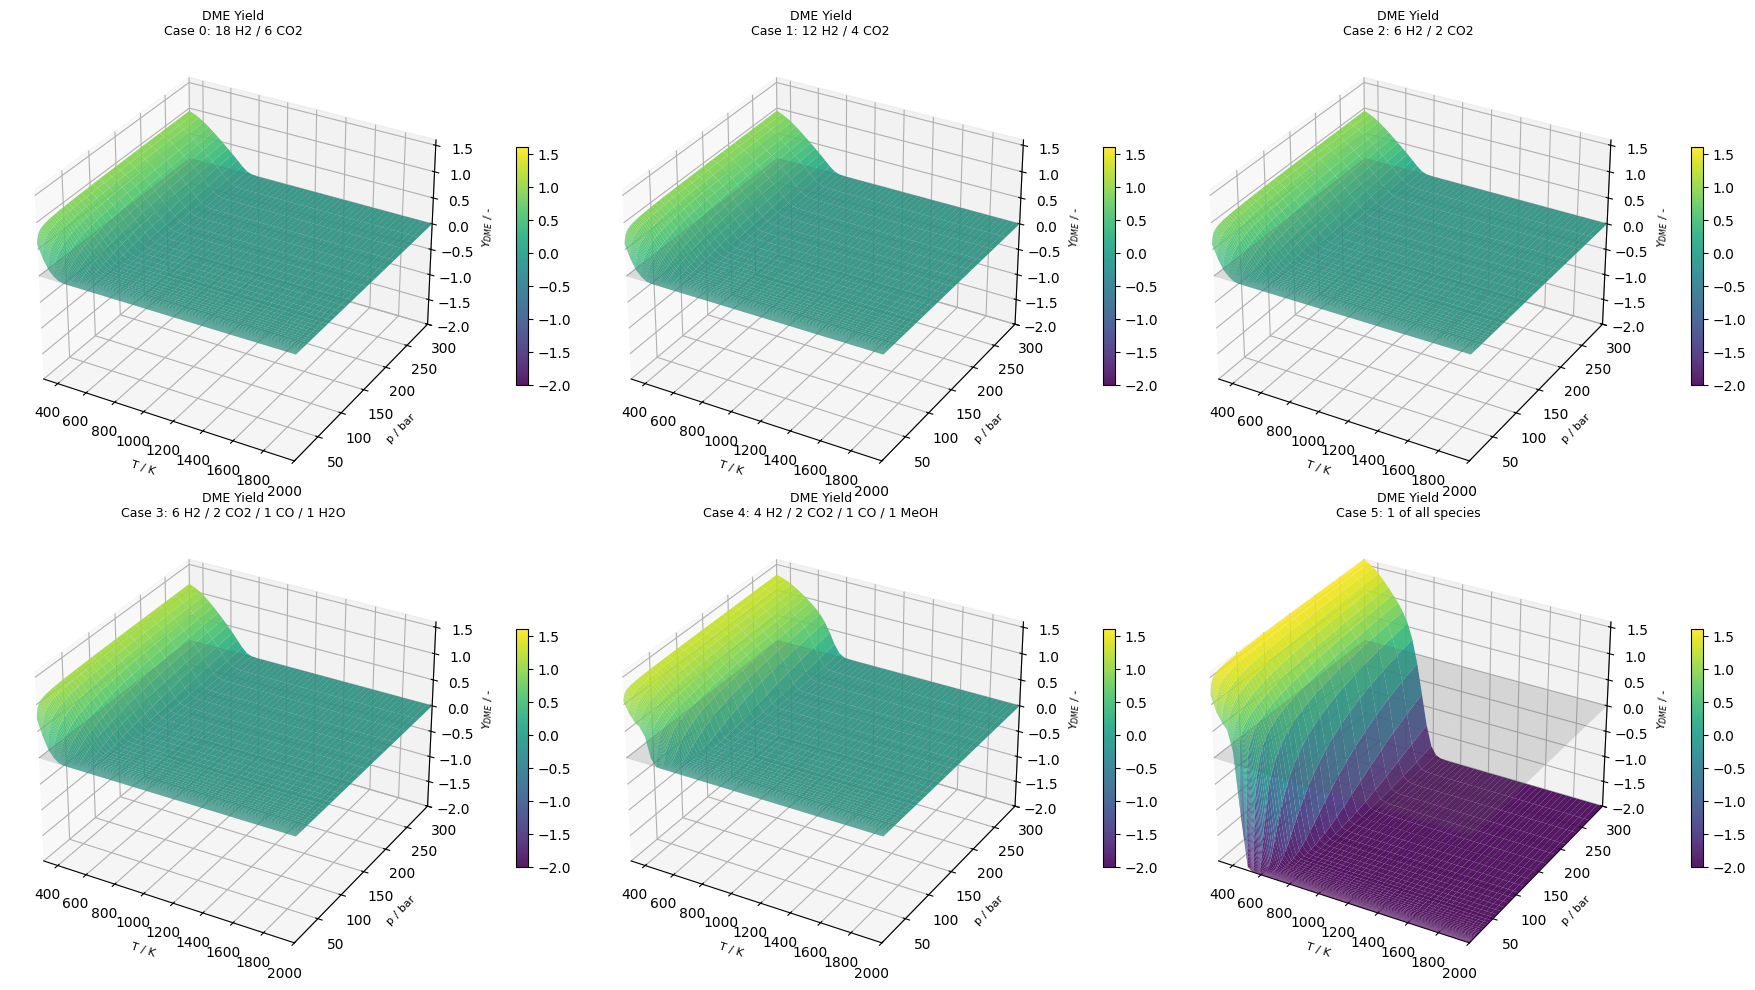

In [19]:
# ====================== 3D-Surface: Y_DME(T,p) for all test cases ======================

# NOTE: for this plot to work, xi_TP_all must be fully computed from the previous section. If you encounter NaNs in Y_DME, ensure that the solver successfully computed xi for all T,p points.

# --- Compute Y_DME for all cases from already calculated xi_TP_all ---
Y_DME_all = np.full((n_cases, len(p_3d), len(T_3d)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for pi in range(len(p_3d)):
        for ti in range(len(T_3d)):
            xi = xi_TP_all[ci, :, pi, ti]
            if np.any(np.isnan(xi)):
                continue
            n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
            Y_DME_all[ci, pi, ti] = dme_yield(n_in, n_out)

# --- Global color scale across all cases ---
vmin_Y = np.nanmin(Y_DME_all)
vmax_Y = np.nanmax(Y_DME_all)

z_plane = np.zeros_like(T_mesh)

# --- Static 3D Plot: 3 cols x 2 rows grid ---
n_cols = 3
n_rows = 2  # ceil(5/3) = 2

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 10),
    subplot_kw={'projection': '3d'}
)

for ci, (name, n_in) in enumerate(test_cases):
    row = ci // n_cols
    col = ci  % n_cols
    ax  = axes[row, col]

    surf = ax.plot_surface(
        T_mesh, p_mesh, Y_DME_all[ci],
        cmap='viridis', alpha=0.9, edgecolor='none',
        vmin=vmin_Y, vmax=vmax_Y
    )
    ax.plot_surface(
        T_mesh, p_mesh, z_plane,
        alpha=0.2, color='gray', edgecolor='none'
    )
    ax.set_xlabel('T / K', fontsize=8)
    ax.set_ylabel('p / bar', fontsize=8)
    ax.set_zlabel(r'$Y_{DME}$ / -', fontsize=8)
    ax.set_title(f'DME Yield\n{name}', fontsize=9)
    ax.set_xlim([T_3d.min(), T_3d.max()])
    ax.set_ylim([p_3d.min(), p_3d.max()])
    ax.set_zlim([vmin_Y, vmax_Y])
    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

# Hide unused subplot (6th cell, index 5)
if n_cases < n_rows * n_cols:
    for empty in range(n_cases, n_rows * n_cols):
        axes[empty // n_cols, empty % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
import math
# ====================== Interactive 3D-Surface: Y_DME(T,p) for all test cases ======================

n_cols = 3
n_rows = math.ceil(n_cases / n_cols)

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    specs=[[{'type': 'surface'} for _ in range(n_cols)] for _ in range(n_rows)],
    subplot_titles=[name for name, _ in test_cases]
)

for ci, (name, n_in) in enumerate(test_cases):
    row = ci // n_cols + 1  # plotly is 1-indexed
    col = ci  % n_cols + 1

    fig.add_trace(
        go.Surface(
            x=T_mesh[0],
            y=p_mesh[:, 0],
            z=Y_DME_all[ci],
            colorscale='Viridis',
            cmin=vmin_Y,
            cmax=vmax_Y,
            showscale=(ci == n_cases - 1),  # colorbar only on last plot
            colorbar=dict(x=1.02, len=0.7) if ci == n_cases - 1 else None,
            name=name,
            hovertemplate='T: %{x:.0f} K<br>p: %{y:.1f} bar<br>Y_DME: %{z:.4f}<extra></extra>'
        ),
        row=row, col=col
    )

# --- Set axis labels for all scenes ---
scene_idx = 1
for ci in range(n_cases):
    key = 'scene' if scene_idx == 1 else f'scene{scene_idx}'
    fig.update_layout(**{
        key: dict(
            xaxis=dict(title='T / K', range=[T_3d.min(), T_3d.max()]),
            yaxis=dict(title='p / bar', range=[p_3d.min(), p_3d.max()]),
            zaxis=dict(title='Y_DME / -', range=[vmin_Y, vmax_Y]),
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
        )
    })
    scene_idx += 1

fig.update_layout(
    title_text='Interactive 3D Surface: Y_DME(T,p) for all test cases',
    width=1800,
    height=600 * n_rows,
    showlegend=False,
    hovermode='closest'
)

fig.show()

# ToDo's for Tomorrow:

- Validating of the plots and getting to know them
- Plotting the reaction extend
- commenting all of the code
- Translating all german comments into english

# Comments on behalf of validation: 

- I used the NIST Thermodynamic Tables as a standart literature to compare our basic results and validate the Results of our Glenn equations. You could also use the DVI Wärmeatlas as an additional reference, if you are feeling we have not enough validated
- I have not had the time or motivation to manually type in the Values for DME and Methanol from different standart literature in my validation of the values after the Glenn equations. Please you do it :D
- please check, if the AI has copied the data in the tables correctly (you dont have to do it for all and everything, but probe a few values please)


# Graveyard of Code

In [21]:

# def root_solver(reaction_list, xi_init, n_in, T, p, reac_index):
#     """
#     Wrapper function for root solver to find the extent of reaction (xi) that satisfies the equilibrium condition.
    
#     Parameters:
#     - reaction_list: A list of lists of tuples representing the reactions. Each tuple contains (species, coefficient). Coefficients should be negative for reactants and positive for products.
#     - xi_init: Initial guesses for the extent of reaction (array of floats).
#     - n_in: Initial moles of each species as an array [mol/h]. MUST have the same order as the species in the reaction dictionary for all reactions R1-R4 (Co, CO2, CH3OCH3, H2, H2O, CH3OH) . MUST be initialized as a float array, else the function will not work properly. (array of floats)
#     - T: Temperature in Kelvin (float).
#     - p: Pressure in bar (float).
#     - reac_index: Indexes of the reactions for which to solve (array of int). R1 = 0, R2 = 1, R4 = 2, R3 = 3.
#     Returns:
#     - xi_solution: Extent of reaction that satisfies the equilibrium condition (float).
#     """
#     def equilibrium_condition(xi):

#         res = np.array([])               # Storage List for results of each reaction
#         n_out = material_balance(reaction_list, xi, n_in, reac_index)  # Get the final moles after the reaction based on the current guess of xi
#         x = mole_fraction(n_out)
#         K_x_1 = eq_const_x(reaction_list[0], T, p)
#         K_x_2 = eq_const_x(reaction_list[1], T, p)
#         K_x_3 = eq_const_x(reaction_list[2], T, p)
#         K_x_4 = eq_const_x(reaction_list[3], T, p)
#         for j in range(len(reac_index)):
#             stoich_coeff_storage = []
#             for i in range(len(reaction_list[j])):
#                 species, coeff = reaction_list[j][i]
#                 stoich_coeff_storage.append(abs(float(coeff)))

#             if reac_index[j] == 0:
#                 res1 = K_x_1 * (x[1]**stoich_coeff_storage[1]) * (x[3]**stoich_coeff_storage[3]) - (x[5]**stoich_coeff_storage[5]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res1)
#             elif reac_index[j] == 1:
#                 res2 = K_x_2 * (x[0]**stoich_coeff_storage[0]) * (x[3]**stoich_coeff_storage[3]) - (x[5]**stoich_coeff_storage[5])
#                 res = np.append(res, res2)
#             elif reac_index[j] == 3:
#                 res3 = K_x_3 * (x[1]**stoich_coeff_storage[1]) * (x[3]**stoich_coeff_storage[3]) - (x[0]**stoich_coeff_storage[0]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res3)
#             elif reac_index[j] == 2:
#                 res4 = K_x_4 * (x[5]**stoich_coeff_storage[5]) - (x[2]**stoich_coeff_storage[2]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res4)

#         return res
#     solution = root(equilibrium_condition, xi_init,method='hybr')
#     return solution.x

# def root_solver_wrapper(reaction_list, xi_init, n_in, T, p, reac_index):
#     """
#     Wrapper function for root solver to find the extent of reaction (xi) that satisfies the equilibrium condition for a list of reactions.
    
#     Parameters:
#     - reaction_list: A list of reactions, where each reaction is a list of tuples representing the reaction. Each tuple contains (species, coefficient). Coefficients should be negative for reactants and positive for products.
#     - xi_init: Initial guess for the extent of reaction (array).
#     - n_in: Initial moles of each species as an array [mol/h]. MUST have the same order as the species in the reaction dictionary for all reactions R1-R4.
#     - T: Temperature in Kelvin (float).
#     - p: Pressure in bar (float).
#     - reac_index: Index of the reaction for which to solve (int). R1 = 0, R2 = 1, R3 = 2, R4 = 3.
    
#     Returns:
#     - xi_solutions: A list of extents of reaction that satisfy the equilibrium condition for each reaction in the list.
#     """
#     xi_solutions = []
#     for i in range(len(reaction_list)):
#         xi_solution = root_solver(reaction_list[i], xi_init, n_in, T, p, reac_index)
#         xi_solutions.append(xi_solution)
#     return xi_solutions


# print(reaction_tuples[0])


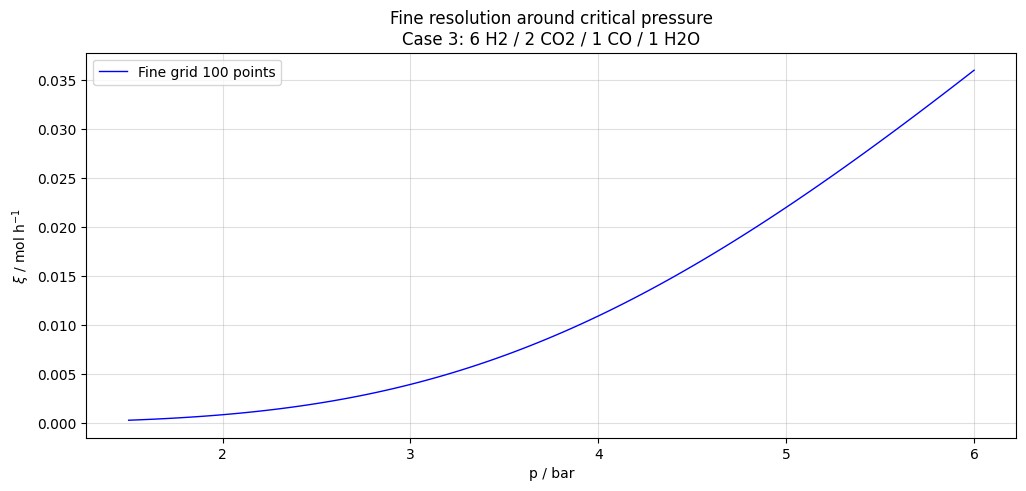

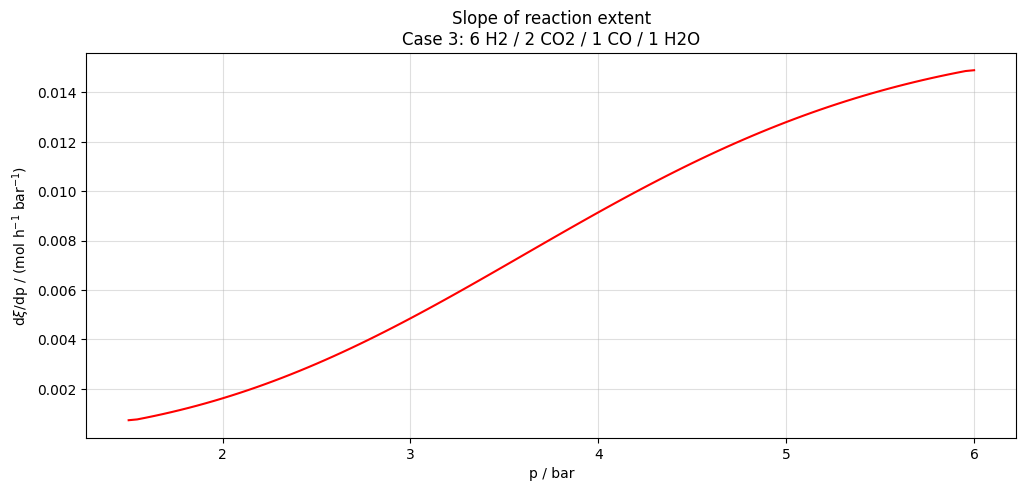

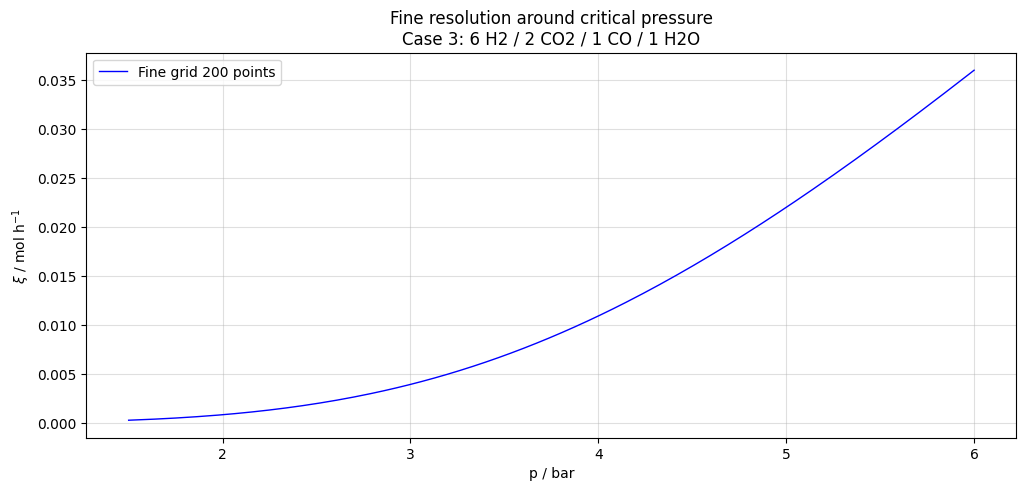

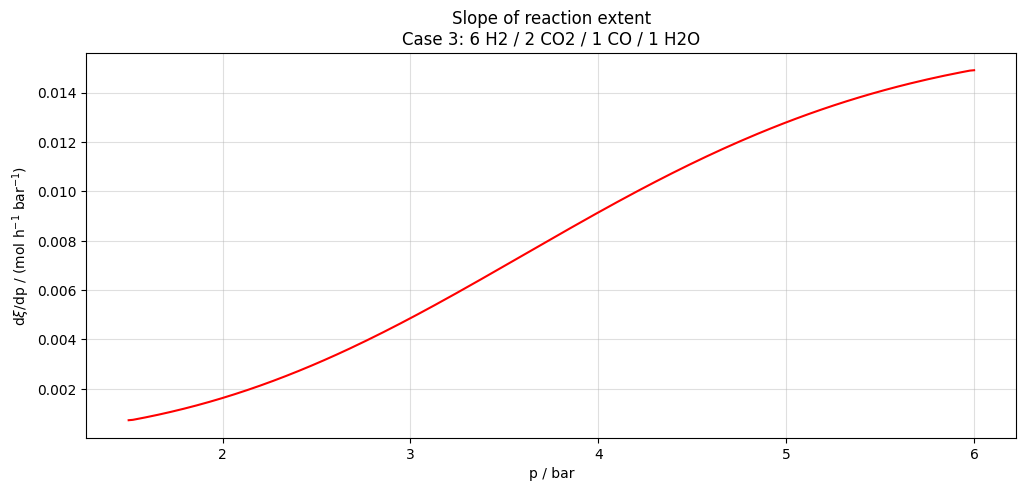

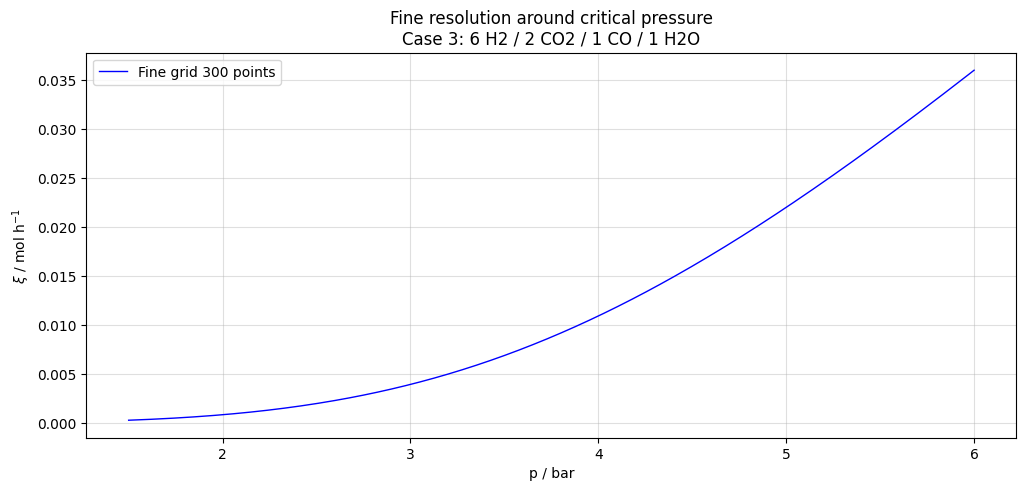

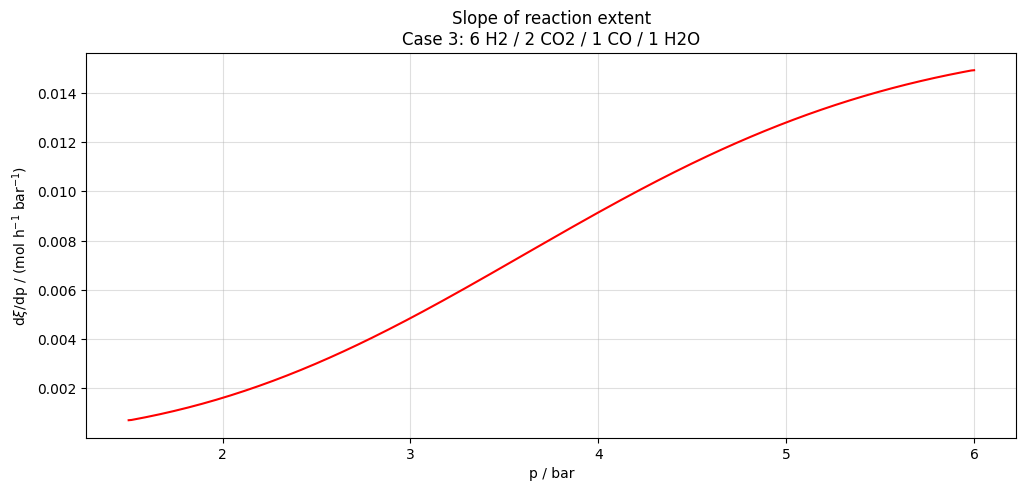

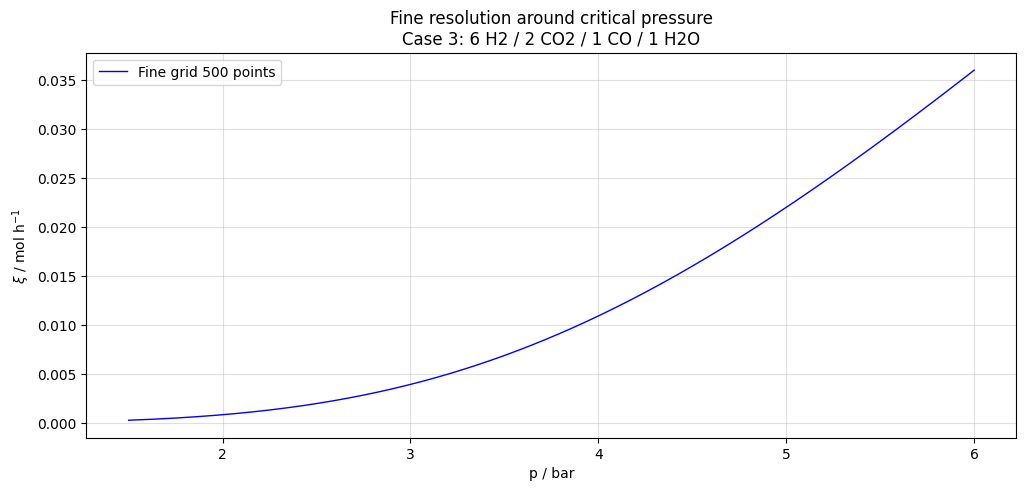

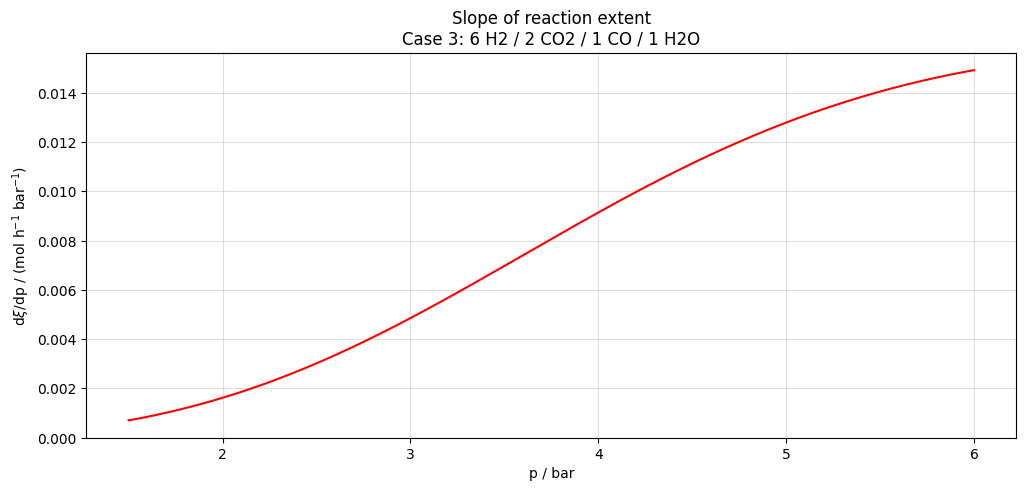

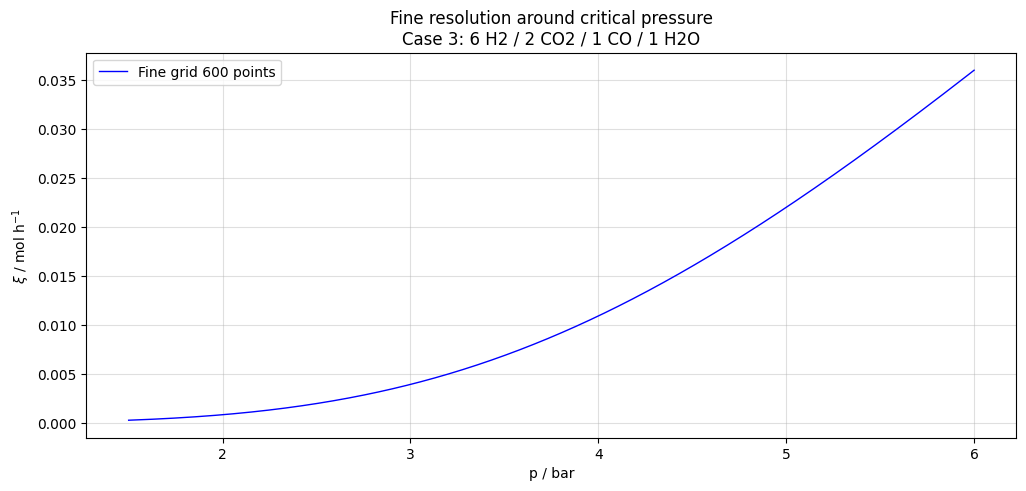

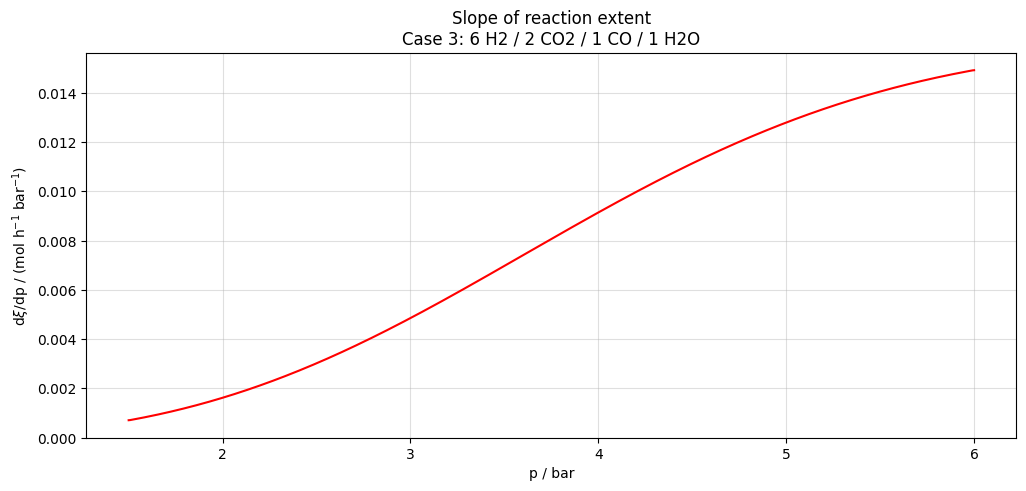

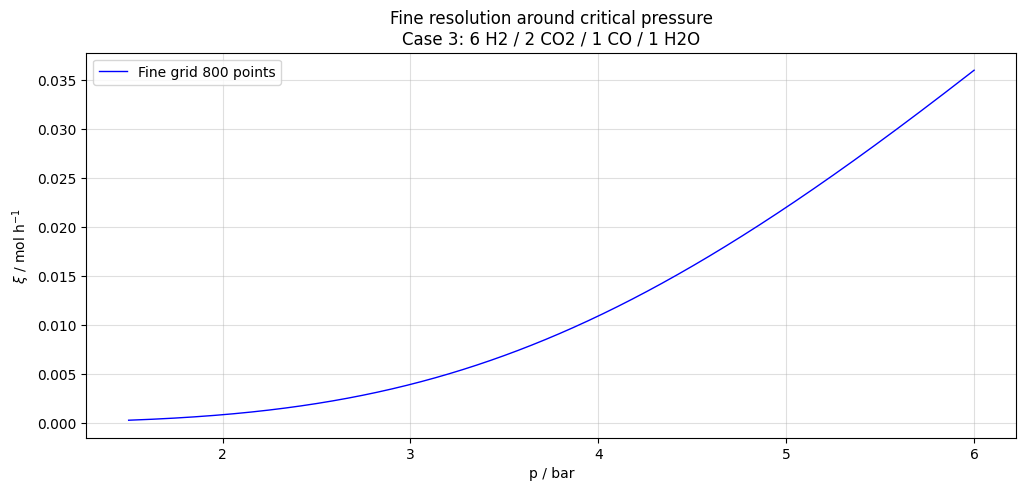

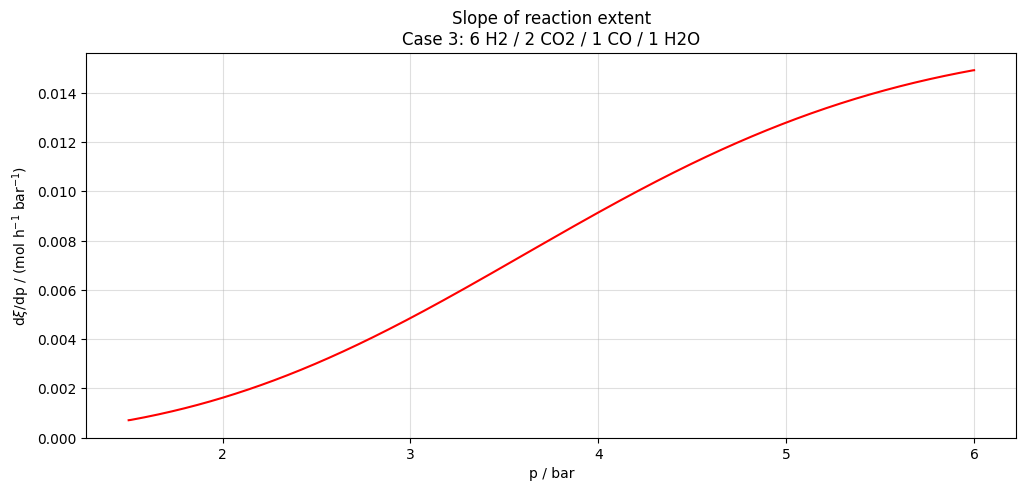

In [22]:
## This shows, that the solver can mathematically come to one single solution, the jumps are just from multiple possible solutions, and subsequently, the wider the single points are apart from each other, the harder the error gets

# Für einen einzelnen Testfall und eine Reaktion:
TEST_IDX = 3
REACTION_IDX = 2
T_test = 500

name, n_in = test_cases[TEST_IDX]

# Suche den ungefähren kritischen Druck aus dem bisherigen Plot
p_crit_approx = 3  # ← Passe das an, wo du die Knickstelle siehst

# Sehr feines Grid um p_crit
p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 100) 

xi_fine = np.full(len(p_fine), np.nan)
xi_prev = np.array([0.001, 0.001, 0.001])

for pi, p in enumerate(p_fine):
    xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_fine[pi] = xi[REACTION_IDX]
        xi_prev = xi

# Plotte mit feiner Auflösung
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 100 points')
ax.set_xlabel('p / bar')
ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
ax.set_title(f'Fine resolution around critical pressure\n{name}')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

# Berechne die numerische Ableitung um die Knickstelle
dxi_dp = np.gradient(xi_fine, p_fine)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
ax.set_xlabel('p / bar')
ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
ax.set_title(f'Slope of reaction extent\n{name}')
ax.grid(True, alpha=0.4)
plt.show()

p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 200) 

xi_fine = np.full(len(p_fine), np.nan)
xi_prev = np.array([0.001, 0.001, 0.001])

for pi, p in enumerate(p_fine):
    xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_fine[pi] = xi[REACTION_IDX]
        xi_prev = xi

# Plotte mit feiner Auflösung
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 200 points')
ax.set_xlabel('p / bar')
ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
ax.set_title(f'Fine resolution around critical pressure\n{name}')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

# Berechne die numerische Ableitung um die Knickstelle
dxi_dp = np.gradient(xi_fine, p_fine)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
ax.set_xlabel('p / bar')
ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
ax.set_title(f'Slope of reaction extent\n{name}')
ax.grid(True, alpha=0.4)
plt.show()

p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 300) 

xi_fine = np.full(len(p_fine), np.nan)
xi_prev = np.array([0.001, 0.001, 0.001])

for pi, p in enumerate(p_fine):
    xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_fine[pi] = xi[REACTION_IDX]
        xi_prev = xi

# Plotte mit feiner Auflösung
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 300 points')
ax.set_xlabel('p / bar')
ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
ax.set_title(f'Fine resolution around critical pressure\n{name}')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

# Berechne die numerische Ableitung um die Knickstelle
dxi_dp = np.gradient(xi_fine, p_fine)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
ax.set_xlabel('p / bar')
ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
ax.set_title(f'Slope of reaction extent\n{name}')
ax.grid(True, alpha=0.4)
plt.show()

p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 500) 

xi_fine = np.full(len(p_fine), np.nan)
xi_prev = np.array([0.001, 0.001, 0.001])

for pi, p in enumerate(p_fine):
    xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_fine[pi] = xi[REACTION_IDX]
        xi_prev = xi

# Plotte mit feiner Auflösung
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 500 points')
ax.set_xlabel('p / bar')
ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
ax.set_title(f'Fine resolution around critical pressure\n{name}')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

# Berechne die numerische Ableitung um die Knickstelle
dxi_dp = np.gradient(xi_fine, p_fine)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
ax.set_xlabel('p / bar')
ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
ax.set_title(f'Slope of reaction extent\n{name}')
ax.grid(True, alpha=0.4)
plt.show()

p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 600) 

xi_fine = np.full(len(p_fine), np.nan)
xi_prev = np.array([0.001, 0.001, 0.001])

for pi, p in enumerate(p_fine):
    xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_fine[pi] = xi[REACTION_IDX]
        xi_prev = xi

# Plotte mit feiner Auflösung
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 600 points')
ax.set_xlabel('p / bar')
ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
ax.set_title(f'Fine resolution around critical pressure\n{name}')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

# Berechne die numerische Ableitung um die Knickstelle
dxi_dp = np.gradient(xi_fine, p_fine)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
ax.set_xlabel('p / bar')
ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
ax.set_title(f'Slope of reaction extent\n{name}')
ax.grid(True, alpha=0.4)
plt.show()

p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 800) 

xi_fine = np.full(len(p_fine), np.nan)
xi_prev = np.array([0.001, 0.001, 0.001])

for pi, p in enumerate(p_fine):
    xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_fine[pi] = xi[REACTION_IDX]
        xi_prev = xi

# Plotte mit feiner Auflösung
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 800 points')
ax.set_xlabel('p / bar')
ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
ax.set_title(f'Fine resolution around critical pressure\n{name}')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

# Berechne die numerische Ableitung um die Knickstelle
dxi_dp = np.gradient(xi_fine, p_fine)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
ax.set_xlabel('p / bar')
ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
ax.set_title(f'Slope of reaction extent\n{name}')
ax.grid(True, alpha=0.4)
plt.show()
